# **Preprocessing for tabular - EDA**

## Import thư viện cần thiết

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import ks_2samp
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.cluster import DBSCAN
from itertools import combinations
file_path = '../data/raw/amazon_products_sales_data_cleaned.csv'
df = pd.read_csv(file_path)
df.head(5)

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


# 1. Xử lý giá trị thiếu có kiểm soát

**Quy trình thực nghiệm đánh giá chiến lược điền khuyết:**

Để đảm bảo tính khách quan và khoa học, thực nghiệm được tiến hành tuần tự qua 4 bước chi tiết:

**Bước 1: Thiết lập tập dữ liệu chuẩn (Ground Truth)**
* Lọc ra một tập con chứa các dòng dữ liệu **hoàn chỉnh 100%** (không bị khuyết bất kỳ cột số nào). 
* Tập con này sẽ đóng vai trò là "Ground Truth" để đối chiếu kết quả.

**Bước 2: Mô phỏng cơ chế thiếu hụt**
* Trên tập Ground Truth, tiến hành "đục lỗ" ngẫu nhiên để tạo ra **10% giá trị thiếu** nhân tạo.
* Việc tạo giá trị thiếu tuân thủ nghiêm ngặt cơ chế MCAR để đảm bảo không mang định kiến vào quá trình thử nghiệm.

**Bước 3: Thực thi thuật toán điền khuyết**
* Áp dụng độc lập 5 chiến lược (Mean, Median, Mode, k-NN Imputation, và MICE) lên tập dữ liệu vừa bị làm khuyết.
* Thuật toán sẽ tính toán và lấp đầy các ô trống nhân tạo này bằng các giá trị dự đoán ($\hat{y}_i$).

**Bước 4: Đo lường sai số và ra quyết định**
* Tính toán chỉ số **RMSE** (Root Mean Squared Error) để đo độ lệch giữa giá trị điền khuyết ($\hat{y}_i$) và giá trị gốc thực tế ($y_i$).


$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

* **Kết luận:** Tổng hợp kết quả thành bảng so sánh. Chiến lược đạt RMSE thấp nhất (sai số nhỏ nhất) sẽ được chọn làm phương pháp điền khuyết chính thức cho toàn bộ tập dữ liệu.




## 1.1. Thiết lập Ground Truth và Mô phỏng dữ liệu khuyết (MCAR)

Bước đầu tiên trong quy trình thực nghiệm là chuẩn bị "môi trường kiểm thử". Nhóm tiến hành tạo lập một tập dữ liệu chuẩn và cố tình làm khuyết nó để đo lường độ chính xác của các thuật toán. Các bước cụ thể bao gồm:

* **Xác định biến mục tiêu :** Quét toàn bộ tập dữ liệu để tự động trích xuất các cột dạng số đang thực sự có chứa giá trị thiếu. Đây là những cột sẽ tham gia trực tiếp vào cuộc thử nghiệm.
* **Xây dựng tập Ground Truth:** Trích lọc một tập con (`df_gt`) bao gồm các quan sát hoàn chỉnh 100% (không chứa giá trị `NaN` tại các cột mục tiêu). Tập dữ liệu sạch này đóng vai trò là "đáp án đúng" để đối chiếu kết quả sau này.
* **Mô phỏng thiếu hụt nhân tạo (MCAR 10%):** Sử dụng một ma trận mặt nạ, thuật toán cố tình "đục lỗ" (thay thế bằng `NaN`) đúng 10% số lượng dòng ngẫu nhiên trên từng cột mục tiêu. Quá trình này mô phỏng cơ chế Missing Completely At Random (MCAR), tạo ra tập thử nghiệm `df_holes` với trạng thái `random_state=42` để đảm bảo tính tái lập.
* **Thiết lập hàm đánh giá (`calc_rmse`):** Xây dựng hàm tính toán sai số Root Mean Squared Error. Điểm đặc biệt của hàm này là nó *chỉ tính sai số tại đúng các tọa độ bị làm khuyết nhân tạo* (thông qua ma trận `mask`), bỏ qua các ô vốn dĩ đã có sẵn dữ liệu. Hàm trả về RMSE chi tiết cho từng cột và RMSE trung bình tổng thể để làm tiêu chí xếp hạng cuối cùng.


In [4]:
# Cột số có missing
TARGET_COLS = df.select_dtypes(include='number').columns[
    df.select_dtypes(include='number').isnull().any()
].tolist()
print(f"Cột số tham gia thí nghiệm ({len(TARGET_COLS)}):")
for c in TARGET_COLS:
    print(f"  • {c}: {df[c].isnull().sum():,} missing ({df[c].isnull().mean()*100:.2f}%)")

# ── Ground truth: hàng hoàn chỉnh ──
df_gt = df.dropna(subset=TARGET_COLS)[TARGET_COLS].reset_index(drop=True)
print(f"\nGround truth: {len(df_gt):,} hàng hoàn chỉnh / {len(df):,} tổng")

# ── Tạo 10% artificial missing MCAR ──
np.random.seed(42)
mask = pd.DataFrame(False, index=df_gt.index, columns=TARGET_COLS)
for col in TARGET_COLS:
    idx = np.random.choice(df_gt.index, size=int(0.10 * len(df_gt)), replace=False)
    mask.loc[idx, col] = True

df_holes = df_gt.copy()
df_holes[mask] = np.nan

print(f"\nSố giá trị bị mask (10% MCAR) trên mỗi cột:")
for c in TARGET_COLS:
    print(f"  • {c}: {mask[c].sum():,}")

# ── Hàm tính RMSE ──
def calc_rmse(truth, imputed, m, cols):
    """Trả về dict {col: rmse, 'Trung bình': avg}"""
    res = {}
    for c in cols:
        t = truth.loc[m[c], c].values
        p = imputed.loc[m[c], c].values
        v = ~(np.isnan(t) | np.isnan(p))
        res[c] = np.sqrt(mean_squared_error(t[v], p[v])) if v.sum() > 0 else np.nan
    vals = [v for v in res.values() if not np.isnan(v)]
    res['Trung bình'] = np.mean(vals) if vals else np.nan
    return res

ALL_RESULTS = {}


Cột số tham gia thí nghiệm (6):
  • product_rating: 1,024 missing (2.40%)
  • total_reviews: 1,024 missing (2.40%)
  • purchased_last_month: 10,511 missing (24.63%)
  • discounted_price: 2,062 missing (4.83%)
  • original_price: 2,062 missing (4.83%)
  • discount_percentage: 2,062 missing (4.83%)

Ground truth: 30,228 hàng hoàn chỉnh / 42,675 tổng

Số giá trị bị mask (10% MCAR) trên mỗi cột:
  • product_rating: 3,022
  • total_reviews: 3,022
  • purchased_last_month: 3,022
  • discounted_price: 3,022
  • original_price: 3,022
  • discount_percentage: 3,022


## 1.2. Điền khuyết theo chiến lược

### Chiến lược 1: Mean Imputation

**1. Cơ chế hoạt động:**

Phương pháp này tiến hành lấp đầy các ô dữ liệu bị khuyết (`NaN`) bằng **trung bình cộng** của toàn bộ các quan sát hợp lệ (không bị khuyết) nằm trong cùng một thuộc tính (cột) đó.

**2. Công thức toán học**
$$\hat{x}_{\text{missing}} = \bar{x} = \frac{1}{n_{\text{obs}}} \sum_{i=1}^{n_{\text{obs}}} x_i$$

*(Trong đó: $n_{\text{obs}}$ là tổng số dòng có dữ liệu hợp lệ tại thuộc tính đang xét, $x_i$ là giá trị thực tế của từng dòng).*

**3. Đánh giá đặc điểm**
* **Ưu điểm:** Tốc độ thực thi cực kỳ nhanh, độ phức tạp tính toán thấp $\mathcal{O}(n)$, dễ cài đặt và giúp bảo toàn được giá trị kỳ vọng (trung bình mẫu) của tập dữ liệu ban đầu.
* **Nhược điểm:** * Làm thu hẹp phương sai (Variance) một cách giả tạo do bơm vào quá nhiều hằng số giống hệt nhau.
    * Phá vỡ cấu trúc tương quan đa biến (Covariance/Correlation) với các thuộc tính khác trong ma trận.
    * Nhạy cảm với nhiễu: Gây ra sai lệch (Bias) cực lớn nếu dữ liệu chứa nhiều giá trị ngoại lai (Outliers) hoặc có phân phối lệch (Skewed Distribution).
* **Giả định ngầm định:** Kỹ thuật này ngầm mặc định rằng dữ liệu của thuộc tính đang xét tuân theo phân phối chuẩn, có tính đối xứng hoàn hảo quanh giá trị trung tâm.



In [5]:
df_imp = df_holes.copy()
for c in TARGET_COLS:
    val = df_holes[c].mean()
    df_imp[c].fillna(val, inplace=True)
    print(f"  {c}: mean = {val:,.4f}")

rmse_mean = calc_rmse(df_gt, df_imp, mask, TARGET_COLS)
ALL_RESULTS['Mean'] = rmse_mean

print("\n RMSE — Mean Imputation:")
for c in TARGET_COLS + ['Trung bình']:
    print(f"   {c:<25s}: {rmse_mean[c]:>12,.4f}")


  product_rating: mean = 4.4386
  total_reviews: mean = 3,687.7229
  purchased_last_month: mean = 1,370.9016
  discounted_price: mean = 155.7624
  original_price: mean = 172.0583
  discount_percentage: mean = 7.8223

 RMSE — Mean Imputation:
   product_rating           :       0.3635
   total_reviews            :  15,951.6020
   purchased_last_month     :   6,221.2701
   discounted_price         :     278.2093
   original_price           :     325.5727
   discount_percentage      :      13.1358
   Trung bình               :   3,798.3589


### Chiến lược 2: Median Imputation

**1. Cơ chế hoạt động**

Phương pháp này tiến hành lấp đầy các ô dữ liệu bị khuyết bằng **Median** của thuộc tính đó. Trung vị là điểm phân vị thứ 50 ($P_{50}$), chia tập dữ liệu (sau khi đã được sắp xếp theo thứ tự độ lớn) thành hai nửa có số lượng quan sát bằng nhau.

**2. Công thức toán học**
$$\hat{x}_{\text{missing}} = \tilde{x} = \begin{cases} x_{\left(\frac{n+1}{2}\right)} & \text{nếu } n \text{ lẻ} \\[6pt] \frac{x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}}{2} & \text{nếu } n \text{ chẵn} \end{cases}$$

*(Trong đó: $n$ là tổng số lượng quan sát hợp lệ, $x_{(i)}$ là giá trị đứng ở vị trí thứ $i$ sau khi tập dữ liệu đã được sắp xếp tăng dần).*

**3. Đánh giá đặc điểm**
* **Ưu điểm:**  **Kháng nhiễu mạnh mẽ:** Khác với Mean, Median hoàn toàn không bị kéo lệch bởi các giá trị cực đoan.
    * Xử lý xuất sắc các thuộc tính có phân phối lệch, vốn rất phổ biến trong dữ liệu thương mại điện tử (như giá tiền, số lượt mua).
* **Nhược điểm:** * Vẫn mang bản chất của phương pháp đơn biến, do đó bỏ qua hoàn toàn mối quan hệ tương quan đa biến giữa các cột.
    * Việc lấp đầy bằng một hằng số duy nhất sẽ tạo ra một đỉnh nhọn giả tạo tại vị trí trung vị trên biểu đồ phân phối, làm giảm phương sai tự nhiên của dữ liệu.
* **Trường hợp áp dụng tối ưu:** Được ưu tiên sử dụng khi dữ liệu vi phạm giả định phân phối chuẩn hoặc khi phát hiện có quá nhiều giá trị ngoại lai thông qua biểu đồ Boxplot.



In [6]:

df_imp = df_holes.copy()
for c in TARGET_COLS:
    val = df_holes[c].median()
    df_imp[c].fillna(val, inplace=True)
    print(f"  {c}: median = {val:,.4f}")

rmse_median = calc_rmse(df_gt, df_imp, mask, TARGET_COLS)
ALL_RESULTS['Median'] = rmse_median

print("\nRMSE — Median Imputation:")
for c in TARGET_COLS + ['Trung bình']:
    print(f"   {c:<25s}: {rmse_median[c]:>12,.4f}")

  product_rating: median = 4.5000
  total_reviews: median = 686.0000
  purchased_last_month: median = 200.0000
  discounted_price: median = 71.9400
  original_price: median = 78.9900
  discount_percentage: median = 0.0000

RMSE — Median Imputation:
   product_rating           :       0.3683
   total_reviews            :  16,249.6703
   purchased_last_month     :   6,300.2113
   discounted_price         :     293.0134
   original_price           :     340.9071
   discount_percentage      :      15.0918
   Trung bình               :   3,866.5437


### Chiến lược 3: Mode Imputation

**1. Cơ chế hoạt động**

Phương pháp này tiến hành lấp đầy các ô dữ liệu bị khuyết bằng **Mode** — tức là giá trị có tần suất xuất hiện nhiều nhất trong tập hợp các quan sát hợp lệ của thuộc tính đó.

**2. Công thức toán học**
$$\hat{x}_{\text{missing}} = \text{mode}(x_{\text{obs}}) = \arg\max_{v} \; \text{count}(x_i = v)$$

*(Trong đó: $v$ đại diện cho một giá trị duy nhất (unique value) trong tập dữ liệu quan sát được $x_{\text{obs}}$, hàm $\arg\max$ trả về giá trị $v$ làm cho số lần đếm (count) đạt mức tối đa).*

**3. Đánh giá đặc điểm**
* **Ưu điểm:** Tính linh hoạt cực cao, là phương pháp thống kê mô tả duy nhất có thể áp dụng trực tiếp cho cả dữ liệu định lượng lẫn dữ liệu định tính/phân loại.
* **Nhược điểm:** * **Rủi ro lớn với dữ liệu liên tục:** Đối với các biến số liên tục (ví dụ: giá tiền, tọa độ), Mode thường là một giá trị mang tính ngẫu nhiên hoặc cực kỳ đặc thù, việc điền khuyết bằng Mode có thể tạo ra độ lệch vô cùng lớn.
    * **Tính bất định:** Nhiều thuộc tính số học không có Mode rõ ràng hoặc có đa đỉnh, khiến Mode nằm cách rất xa khu vực trung tâm dữ liệu (so với Mean hoặc Median).
* **Trường hợp áp dụng tối ưu:** Đây là giải pháp thường dành cho dữ liệu phân loại. Tuy nhiên, đối với dữ liệu số học, chiến lược này thường đóng vai trò là đường cơ sở có hiệu suất kém nhất và rất hiếm khi được ưu tiên trong thực tiễn, trừ phi biến số đó là dữ liệu rời rạc có rất ít giá trị khả dĩ.


In [7]:
df_imp = df_holes.copy()
for c in TARGET_COLS:
    col_mode = df_holes[c].mode()
    val = col_mode.iloc[0] if len(col_mode) > 0 else df_holes[c].median()
    df_imp[c].fillna(val, inplace=True)
    print(f"  {c}: mode = {val:,.4f}")

rmse_mode = calc_rmse(df_gt, df_imp, mask, TARGET_COLS)
ALL_RESULTS['Mode'] = rmse_mode

print("\n RMSE — Mode Imputation:")
for c in TARGET_COLS + ['Trung bình']:
    print(f"   {c:<25s}: {rmse_mode[c]:>12,.4f}")


  product_rating: mode = 4.6000
  total_reviews: mode = 84.0000
  purchased_last_month: mode = 100.0000
  discounted_price: mode = 29.9900
  original_price: mode = 29.9900
  discount_percentage: mode = 0.0000

 RMSE — Mode Imputation:
   product_rating           :       0.3969
   total_reviews            :  16,375.1689
   purchased_last_month     :   6,316.9748
   discounted_price         :     308.8125
   original_price           :     358.5523
   discount_percentage      :      15.0918
   Trung bình               :   3,895.8329


### Chiến lược 4: Điền khuyết bằng K-Láng giềng gần nhất (k-NN Imputation)

**1. Cơ chế hoạt động:**

Thay vì sử dụng một đại lượng thống kê chung cho toàn bộ tập dữ liệu, thuật toán tiến hành quét ma trận để tìm ra $k$ hàng "tương đồng nhất" với dòng đang bị khuyết. Mức độ tương đồng được xác định dựa trên khoảng cách của các thuộc tính không bị thiếu. Giá trị điền khuyết cuối cùng sẽ là trung bình cộng của $k$ láng giềng gần nhất này.

**2. Công thức toán học**
Giá trị dự đoán cho thuộc tính bị thiếu tại quan sát $i$ được tính bằng:
$$\hat{x}_{\text{missing}}^{(i)} = \frac{1}{k} \sum_{j \in \mathcal{N}_k(i)} x_j$$

*(Trong đó: $\mathcal{N}_k(i)$ là tập hợp $k$ láng giềng gần nhất của quan sát $i$).* Để tìm ra tập $\mathcal{N}_k(i)$, thuật toán đo lường bình phương khoảng cách Euclidean trên các tập thuộc tính $m$ quan sát được (không chứa `NaN`) giữa hai dòng $i$ và $j$:
$$d(i, j) = \sqrt{\sum_{m \in \text{obs}} \left( x_i^{(m)} - x_j^{(m)} \right)^2}$$

**3. Đánh giá đặc điểm**
* **Ưu điểm:** * Khai thác triệt để **cấu trúc đa biến** của dữ liệu. (Ví dụ: Trên Amazon, các sản phẩm có cùng mức Rating và lượt Review tương tự sẽ tự động "đóng góp" giá trị cho mức Giá đang bị khuyết của nhau).
    * Là thuật toán phi tham số, không yêu cầu dữ liệu phải tuân thủ bất kỳ giả định phân phối nào (như phân phối chuẩn).
* **Nhược điểm:** * Cực kỳ nhạy cảm với thang đo. Bắt buộc phải thực hiện chuẩn hóa dữ liệu trước khi tính khoảng cách.
    * Chi phí bộ nhớ và thời gian tính toán lớn $\mathcal{O}(n^2)$ do phải tạo ma trận khoảng cách cho toàn bộ tập dữ liệu.
* **Tối ưu hóa siêu tham số:** Hiệu suất phụ thuộc mạnh vào việc lựa chọn số lượng láng giềng $k \in \{3, 5, 10\}$. Nếu $k$ quá nhỏ, mô hình nhạy cảm với nhiễu ; nếu $k$ quá lớn, kết quả bị làm mịn quá mức và dần thoái hóa về phương pháp điền Mean.


In [8]:
scaler = StandardScaler()
temp_filled = df_holes.fillna(df_holes.median())            
scaler.fit(temp_filled)

df_holes_scaled = pd.DataFrame(
    scaler.transform(temp_filled), columns=TARGET_COLS, index=df_holes.index
)

df_holes_scaled[mask] = np.nan

for k in [3, 5, 10]:
    print(f"\n── k-NN (k={k}) ──")
    imputer = KNNImputer(n_neighbors=k, weights='uniform')
    arr = imputer.fit_transform(df_holes_scaled)
    # Inverse về scale gốc
    df_imp = pd.DataFrame(
        scaler.inverse_transform(arr), columns=TARGET_COLS, index=df_holes.index
    )

    rmse_knn = calc_rmse(df_gt, df_imp, mask, TARGET_COLS)
    ALL_RESULTS[f'k-NN (k={k})'] = rmse_knn

    print(f" RMSE:")
    for c in TARGET_COLS + ['Trung bình']:
        print(f"     {c:<25s}: {rmse_knn[c]:>12,.4f}")



── k-NN (k=3) ──
 RMSE:
     product_rating           :       0.2067
     total_reviews            :  15,002.1104
     purchased_last_month     :   2,731.6327
     discounted_price         :     192.7826
     original_price           :     188.1761
     discount_percentage      :       7.7489
     Trung bình               :   3,020.4429

── k-NN (k=5) ──
 RMSE:
     product_rating           :       0.1855
     total_reviews            :  14,790.5577
     purchased_last_month     :   2,682.0693
     discounted_price         :     183.7992
     original_price           :     173.5269
     discount_percentage      :       6.9120
     Trung bình               :   2,972.8418

── k-NN (k=10) ──
 RMSE:
     product_rating           :       0.1665
     total_reviews            :  14,641.7761
     purchased_last_month     :   2,645.6344
     discounted_price         :     180.3641
     original_price           :     157.4191
     discount_percentage      :       6.4098
     Trung bình         

### Chiến lược 5: MICE - Multiple Imputation by Chained Equations

**1. Cơ chế hoạt động:**

MICE (được triển khai trong Scikit-learn dưới dạng `IterativeImputer`) là một kỹ thuật mô hình hóa lặp. Thay vì tính toán một lần, thuật toán xem mỗi thuộc tính có giá trị thiếu là một "biến phụ thuộc" và các thuộc tính còn lại là "biến độc lập" (Features). Nó sử dụng các mô hình học máy (mặc định là `BayesianRidge`) để dự đoán và lấp đầy các khoảng trống thông qua nhiều vòng lặp liên tiếp cho đến khi kết quả hội tụ.

**2. Công thức toán học và Thuật toán**
Tại mỗi vòng lặp $t \in \{1, 2, \dots, T\}$ (với $T$ mặc định là 10), giá trị điền khuyết cho biến $x_j$ được cập nhật dựa trên phân phối xác suất có điều kiện:

$$x_j^{(t)} \sim P\!\left(x_j \;\middle|\; \mathbf{x}_{-j}^{(t)},\; \hat{\theta}_j^{(t)}\right)$$

**Chuỗi thực thi chi tiết (Chained Equations):**
* **Khởi tạo (Vòng 0):** Lấp đầy tạm thời toàn bộ các ô `NaN` bằng một giá trị cơ sở (ví dụ: Trung vị - Median).
* **Vòng lặp $t$:**
    1. Trích xuất biến $x_1$, đưa các ô vừa điền tạm về lại `NaN`. Fit mô hình hồi quy $x_1 = f(x_2, x_3, \ldots, x_p)$ trên các quan sát hợp lệ để dự đoán và cập nhật lại các ô khuyết của $x_1$.
    2. Chuyển sang biến $x_2$, sử dụng giá trị $x_1$ **vừa được cập nhật** cùng các biến khác để dự đoán khoảng trống của $x_2$.
    3. Lặp lại quá trình trượt qua tất cả các biến $x_j$.
* **Hội tụ:** Quá trình dừng lại khi đạt đến số vòng lặp tối đa ($T$) hoặc khi sự khác biệt giữa hai vòng lặp liên tiếp nhỏ hơn ngưỡng dung sai.

**3. Đánh giá đặc điểm**
* **Ưu điểm:**
    * **State-of-the-Art (SOTA):** Là tiêu chuẩn vàng hiện tại cho bài toán điền khuyết. Khai thác triệt để **toàn bộ cấu trúc tương quan tuyến tính (và phi tuyến)** giữa các biến.
    * Bảo toàn tuyệt đối phương sai tự nhiên và độ tin cậy thống kê của tập dữ liệu.
* **Nhược điểm:**
    * Chi phí tài nguyên và thời gian tính toán lớn nhất trong tất cả các phương pháp.
    * Kết quả phụ thuộc vào việc lựa chọn mô hình hồi quy cơ sở (Base Estimator).
* **Giả định cốt lõi:** Kỹ thuật này phát huy sức mạnh tối đa dưới cơ chế thiếu hụt **MAR** — tức là xác suất một ô bị thiếu có thể được giải thích/dự báo thông qua các biến quan sát được khác trong tập dữ liệu.







In [9]:
print("── MICE (IterativeImputer, max_iter=10, BayesianRidge) ──\n")

mice = IterativeImputer(
    max_iter=10,
    random_state=42,
    initial_strategy='median',
    tol=1e-3
)

arr = mice.fit_transform(df_holes[TARGET_COLS])
df_imp = pd.DataFrame(arr, columns=TARGET_COLS, index=df_holes.index)

rmse_mice = calc_rmse(df_gt, df_imp, mask, TARGET_COLS)
ALL_RESULTS['MICE'] = rmse_mice

print("RMSE — MICE:")
for c in TARGET_COLS + ['Trung bình']:
    print(f"   {c:<25s}: {rmse_mice[c]:>12,.4f}")


── MICE (IterativeImputer, max_iter=10, BayesianRidge) ──

RMSE — MICE:
   product_rating           :       0.3453
   total_reviews            :  15,475.0376
   purchased_last_month     :   6,050.7590
   discounted_price         :     134.0665
   original_price           :     155.0518
   discount_percentage      :      12.3458
   Trung bình               :   3,637.9343


## 1.3. Tổng kết

In [10]:

rows = []
for name, res in ALL_RESULTS.items():
    row = {'Chiến lược': name}
    for c in TARGET_COLS:
        row[c] = round(res[c], 4)
    row['RMSE TB'] = round(res['Trung bình'], 4)
    rows.append(row)

comparison_df = pd.DataFrame(rows).sort_values('RMSE TB').reset_index(drop=True)
comparison_df.insert(0, 'Hạng', range(1, len(comparison_df) + 1))

display(comparison_df.style.set_caption("BẢNG SO SÁNH RMSE — 5 chiến lược ĐIỀN KHUYẾT"))

# Biến lưu kết quả
BEST_NAME  = comparison_df.iloc[0]['Chiến lược']
BEST_RMSE  = comparison_df.iloc[0]['RMSE TB']

WORST_NAME = comparison_df.iloc[-1]['Chiến lược']
WORST_RMSE = comparison_df.iloc[-1]['RMSE TB']
IMPROVEMENT = (WORST_RMSE - BEST_RMSE) / WORST_RMSE * 100

print(f"\nTốt nhất : {BEST_NAME} (RMSE TB = {BEST_RMSE:,.4f})")
print(f"Kém nhất : {WORST_NAME} (RMSE TB = {WORST_RMSE:,.4f})")
print(f"Cải thiện: {IMPROVEMENT:.1f}%")


,Hạng,Chiến lược,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage,RMSE TB
0,1,k-NN (k=10),0.166500,14641.776100,2645.634400,180.364100,157.419100,6.409800,2938.628300
1,2,k-NN (k=5),0.185500,14790.557700,2682.069300,183.799200,173.526900,6.912000,2972.841800
2,3,k-NN (k=3),0.206700,15002.110400,2731.632700,192.782600,188.176100,7.748900,3020.442900
3,4,MICE,0.345300,15475.037600,6050.759000,134.066500,155.051800,12.345800,3637.934300
4,5,Mean,0.363500,15951.602000,6221.270100,278.209300,325.572700,13.135800,3798.358900
5,6,Median,0.368300,16249.670300,6300.211300,293.013400,340.907100,15.091800,3866.543700
6,7,Mode,0.396900,16375.168900,6316.974800,308.812500,358.552300,15.091800,3895.832900



Tốt nhất : k-NN (k=10) (RMSE TB = 2,938.6283)
Kém nhất : Mode (RMSE TB = 3,895.8329)
Cải thiện: 24.6%


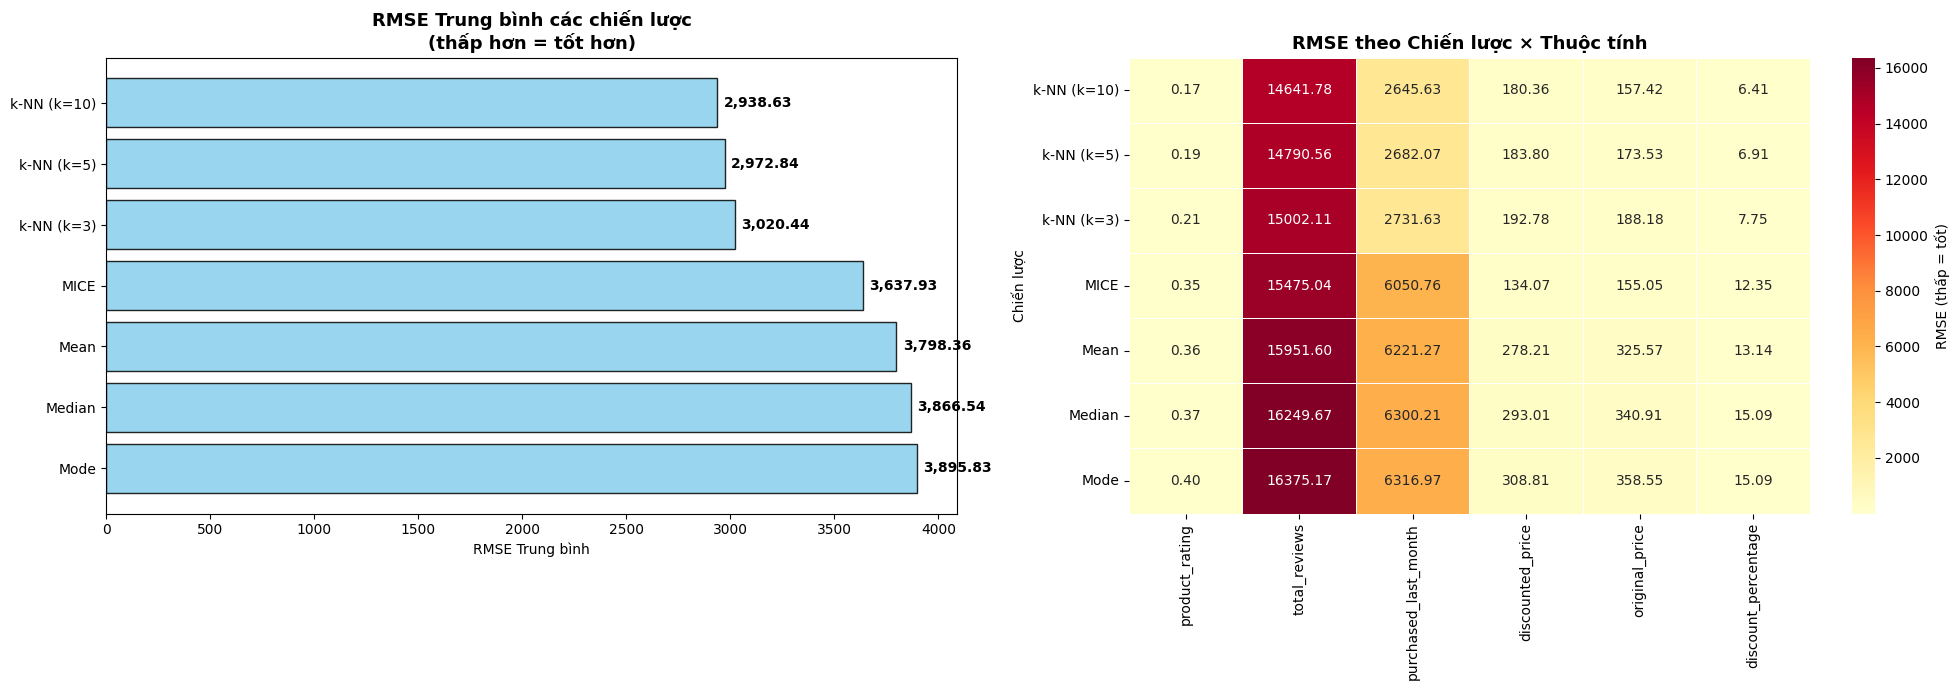

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

names = comparison_df['Chiến lược'].tolist()
vals  = comparison_df['RMSE TB'].tolist()

bars = axes[0].barh(names[::-1], vals[::-1], color='skyblue',
                     edgecolor='black', alpha=0.85)
axes[0].set_xlabel('RMSE Trung bình')
axes[0].set_title('RMSE Trung bình các chiến lược\n(thấp hơn = tốt hơn)',
                   fontweight='bold', fontsize=13)
for bar, v in zip(bars, vals[::-1]):
    axes[0].text(v + max(vals)*0.008, bar.get_y() + bar.get_height()/2,
                 f'{v:,.2f}', va='center', fontsize=10, fontweight='bold')

# ── 2) Heatmap RMSE chi tiết ──
heat = comparison_df.set_index('Chiến lược')[TARGET_COLS]
sns.heatmap(heat, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=.5, ax=axes[1],
            cbar_kws={'label': 'RMSE (thấp = tốt)'})
axes[1].set_title('RMSE theo Chiến lược × Thuộc tính',
                   fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()


In [12]:
col_analysis_rows = []
wins = {}

for c in TARGET_COLS:
    # Trích xuất RMSE hợp lệ
    col_scores = {
        name: ALL_RESULTS[name][c] 
        for name in ALL_RESULTS if not np.isnan(ALL_RESULTS[name][c])
    }
    
    # Xác định chiến lược tốt/kém và tỷ lệ cải thiện
    best = min(col_scores, key=col_scores.get)
    worst = max(col_scores, key=col_scores.get)
    imp = (col_scores[worst] - col_scores[best]) / col_scores[worst] * 100
    
    # Đưa vào list dòng
    col_analysis_rows.append({
        'Thuộc tính': c,
        'Chiến lược tốt nhất': best,
        'RMSE (Tốt nhất)': col_scores[best],
        'Chiến lược kém nhất': worst,
        'RMSE (Kém nhất)': col_scores[worst],
        'Cải thiện (%)': imp
    })
    
    wins[best] = wins.get(best, 0) + 1

df_col_analysis = pd.DataFrame(col_analysis_rows)

display(df_col_analysis)




,Thuộc tính,Chiến lược tốt nhất,RMSE (Tốt nhất),Chiến lược kém nhất,RMSE (Kém nhất),Cải thiện (%)
0,product_rating,k-NN (k=10),0.166466,Mode,0.396856,58.053941
1,total_reviews,k-NN (k=10),14641.776082,Mode,16375.168870,10.585496
2,purchased_last_month,k-NN (k=10),2645.634413,Mode,6316.974836,58.118649
3,discounted_price,MICE,134.066455,Mode,308.812499,56.586454
4,original_price,MICE,155.051845,Mode,358.552306,56.756143
5,discount_percentage,k-NN (k=10),6.409782,Median,15.091758,57.527930




## 1.4. Phân tích kết quả và đánh giá chiến lược

**1.4.1. Đánh giá tổng quan hiệu năng**
Dựa trên bảng đối chiếu sai số cục bộ (RMSE), nhóm rút ra các nhận định quan trọng sau về cấu trúc dữ liệu và hiệu quả của các thuật toán:

* **Sự áp đảo của các thuật toán đa biến:** Các phương pháp phân tích tương quan nhiều chiều (k-NN và MICE) hoàn toàn áp đảo tại tất cả 6 thuộc tính. Việc chuyển đổi từ phương pháp đơn biến (Mode/Median) sang các mô hình học máy đa biến giúp cải thiện sai số vô cùng mạnh mẽ (mức độ cải thiện dao động từ 10.5% đến hơn 58.1%). Điều này khẳng định tập dữ liệu thương mại điện tử Amazon sở hữu mạng lưới tương quan đa chiều chặt chẽ (ví dụ: giá cả, lượt đánh giá và doanh số có sự ràng buộc mật thiết), do đó không thể xử lý hiệu quả bằng các phép tính thống kê cào bằng (cắt rời từng cột).
* **Hạn chế của phương pháp Yếu vị (Mode):** Đúng như giả định lý thuyết, Mode đóng vai trò là "baseline" kém hiệu quả nhất đối với dữ liệu số liên tục. Việc điền khuyết bằng giá trị xuất hiện nhiều nhất đã tạo ra độ lệch (bias) khổng lồ, khiến Mode xếp cuối bảng ở 5/6 thuộc tính thử nghiệm.

**1.4.2. Đánh giá chi tiết theo nhóm đặc trưng**
Kết quả thực nghiệm cho thấy sự phân hóa rõ rệt về độ hiệu quả của thuật toán tùy thuộc vào bản chất của từng biến số:

* **Nhóm biến Tương tác & Hành vi (`product_rating`, `total_reviews`, `purchased_last_month`, `discount_percentage`):** Chiến lược **k-NN (k=10)** giành chiến thắng tuyệt đối tại 4/6 thuộc tính này. Điều này phản ánh tính chất "phân cụm cục bộ" của thị trường: Những sản phẩm tương đồng về phân khúc hoặc tính năng sẽ có xu hướng nhận được lượng tương tác và đánh giá giống nhau. Việc tham số $k=10$ đạt tối ưu cho thấy mô hình cần một không gian "láng giềng" đủ rộng để làm mịn các nhiễu động ngẫu nhiên từ hành vi của người dùng.
* **Nhóm biến Giá trị định lượng (`discounted_price`, `original_price`):** Chiến lược **MICE (IterativeImputer)** tỏ ra vượt trội hoàn toàn. Nguyên nhân cốt lõi về mặt toán học là do hai biến giá này có mối quan hệ tương quan tuyến tính cực kỳ mạnh mẽ. Chuỗi phương trình hồi quy đa biến (BayesianRidge) bên trong thuật toán MICE được thiết kế tối ưu để nắm bắt chính xác các đường thẳng hồi quy này, mang lại độ chính xác cao hơn hẳn so với phép đo khoảng cách hình học đơn thuần của k-NN.

**1.4.3. Tổng kết Chiến lược Tốt nhất**
Dựa trên các số liệu định lượng, nhóm tổng kết chiến lược tốt nhất theo 2 góc độ đánh giá:

* **Xét theo RMSE trung bình tổng thể (Global Performance):** Chiến lược **k-NN (k=10)** là phương pháp tốt nhất. Với RMSE trung bình đạt mức **2,938.63**, k-NN (k=10) vượt trội hoàn toàn so với MICE (3,637.93) và các phương pháp thống kê đơn biến. Nếu buộc phải chọn một chiến lược duy nhất cho toàn bộ dữ liệu, đây sẽ là lựa chọn mang lại sự ổn định cao nhất.
* **Xét theo từng thuộc tính (Feature-level Performance):** Kết quả chiến thắng được phân hóa rõ rệt thành 2 nhóm dựa trên bản chất của biến:
    * Nhóm thuộc tính Tương tác & Hành vi (`product_rating`, `total_reviews`, `purchased_last_month`, `discount_percentage`): **k-NN (k=10)** là chiến lược tốt nhất.
    * Nhóm thuộc tính Giá cả (`discounted_price`, `original_price`): **MICE** là chiến lược tốt nhất, nhờ nắm bắt tốt mối quan hệ tuyến tính giữa giá gốc và giá giảm.
    
**1.4.4. Quyết định triển khai: Áp dụng Chiến lược Điền khuyết Hỗn hợp (Hybrid Imputation)**
Thay vì sử dụng một phương pháp duy nhất cho toàn bộ tập dữ liệu và phải chấp nhận sự đánh đổi sai số ở một số thuộc tính nhất định, nhóm quyết định điền khuyết Hỗn hợp. Mục tiêu là để ép sai số cục bộ (Local RMSE) của từng cột xuống mức cực tiểu. Cụ thể quy trình áp dụng như sau:

1. **Với cụm biến Giá trị định lượng (`discounted_price`, `original_price`):** Áp dụng chuyên biệt thuật toán **MICE (IterativeImputer)**. Việc này giúp tận dụng thế mạnh của mô hình BayesianRidge bên trong MICE để dự báo chính xác các biến có mối quan hệ cấu trúc chặt chẽ (giá gốc và giá giảm).
2. **Với cụm biến Tương tác & Hành vi (`product_rating`, `total_reviews`, `purchased_last_month`, `discount_percentage`):** Áp dụng thuật toán **k-NN Imputation (với k=10)**. k-NN sẽ phát huy tối đa hiệu quả trong việc nội suy giá trị thông qua việc tìm kiếm các sản phẩm "láng giềng" có độ tương đồng cao về phân khúc thị trường.

**Kết luận:** Việc mạnh dạn kết hợp cả 2 thuật toán SOTA (State-of-the-Art) đảm bảo rằng mỗi điểm dữ liệu khuyết đều được khôi phục ổn định. Phương pháp tiếp cận này giúp tập dữ liệu Amazon đạt được trạng thái lý tưởng và toàn vẹn nhất trước khi đưa vào huấn luyện các mô hình Machine Learning chuyên sâu.

In [13]:
df_final = df.copy()

print("Trạng thái Missing TRƯỚC khi điền:")
for c in TARGET_COLS:
    print(f"  • {c:<25s}: {df_final[c].isnull().sum():>6,} dòng")


mice_cols = ['discounted_price', 'original_price']
knn_cols  = [c for c in TARGET_COLS if c not in mice_cols]


mice_imputer = IterativeImputer(max_iter=10, random_state=42, initial_strategy='median')
mice_arr = mice_imputer.fit_transform(df_final[TARGET_COLS])
df_mice = pd.DataFrame(mice_arr, columns=TARGET_COLS, index=df_final.index)

df_final[mice_cols] = df_mice[mice_cols]


scaler = StandardScaler()
temp_filled = df_final[TARGET_COLS].fillna(df_final[TARGET_COLS].median())
scaler.fit(temp_filled)

df_final_scaled = pd.DataFrame(
    scaler.transform(temp_filled), columns=TARGET_COLS, index=df_final.index
)

for c in knn_cols:
    df_final_scaled.loc[df_final[c].isnull(), c] = np.nan

knn_imputer = KNNImputer(n_neighbors=10, weights='uniform')
knn_arr_scaled = knn_imputer.fit_transform(df_final_scaled)
df_knn = pd.DataFrame(
    scaler.inverse_transform(knn_arr_scaled), columns=TARGET_COLS, index=df_final.index
)

df_final[knn_cols] = df_knn[knn_cols]

print("\nTrạng thái Missing SAU khi điền:")
for c in TARGET_COLS:
    print(f"  • {c:<25s}: {df_final[c].isnull().sum():>6,} dòng")

print(f"\nTổng missing còn lại trên nhóm biến số học: "
      f"{df_final[TARGET_COLS].isnull().sum().sum()}")
df = df_final

Trạng thái Missing TRƯỚC khi điền:
  • product_rating           :  1,024 dòng
  • total_reviews            :  1,024 dòng
  • purchased_last_month     : 10,511 dòng
  • discounted_price         :  2,062 dòng
  • original_price           :  2,062 dòng
  • discount_percentage      :  2,062 dòng

Trạng thái Missing SAU khi điền:
  • product_rating           :      0 dòng
  • total_reviews            :      0 dòng
  • purchased_last_month     :      0 dòng
  • discounted_price         :      0 dòng
  • original_price           :      0 dòng
  • discount_percentage      :      0 dòng

Tổng missing còn lại trên nhóm biến số học: 0


# 2. Phát hiện và xử lý ngoại lai 

**Mục tiêu:**
Trong các tập dữ liệu thực tế như Amazon, giá trị ngoại lai có thể xuất phát từ lỗi ghi nhận dữ liệu hoặc đại diện cho những hiện tượng kinh doanh đột biến (ví dụ: món đồ có giá cực cao, hoặc lượng đánh giá khổng lồ). Việc loại bỏ ngoại lai mù quáng có thể làm mất đi các tín hiệu quan trọng. 

Do đó, mục tiêu của phần này là áp dụng hệ thống đa phương pháp để nhận diện ngoại lai một cách thận trọng. Nhóm sẽ tiến hành đối chiếu kết quả giữa các không gian thuật toán khác nhau (Thống kê, Cây quyết định, Khoảng cách và Mật độ) nhằm tìm ra một tập hợp ngoại lai "đồng thuận" nhất, đồng thời đánh giá tác động của việc loại bỏ chúng lên cấu trúc phân phối của dữ liệu.

**Các phương pháp tiếp cận**
Theo yêu cầu thực nghiệm, nhóm tiến hành cài đặt và cấu hình 4 nhóm kỹ thuật phát hiện ngoại lai chuyên sâu:

1. **Phương pháp Thống kê cổ điển (Statistical Methods):**
   * **IQR (Interquartile Range):** Phương pháp phi tham số, phát hiện ngoại lai dựa trên biên độ trải giữa $Q1$ và $Q3$. Kháng nhiễu tốt với các phân phối lệch.
   * **Z-Score:** Phương pháp tham số, giả định dữ liệu tuân theo phân phối chuẩn. Xác định ngoại lai là các điểm có độ lệch chuẩn $|Z| > 3$.

2. **Isolation Forest (iForest):**
   * Thuật toán dựa trên mô hình tập hợp cây (Ensemble Tree). iForest "cô lập" các điểm ngoại lai bằng cách phân chia ngẫu nhiên không gian đặc trưng. Những điểm bị cô lập với số lần cắt (path length) ngắn nhất sẽ bị coi là ngoại lai.
   * *Thực nghiệm đa cấu hình:* Khảo sát mức độ ô nhiễm $\text{contamination} \in \{0.01, 0.05, 0.1\}$.

3. **Local Outlier Factor (LOF):**
   * Thuật toán dựa trên mật độ cục bộ (Local Density). Đánh giá mức độ bất thường của một điểm dữ liệu bằng cách so sánh mật độ của nó với mật độ của các vùng lân cận.
   * *Thực nghiệm đa cấu hình:* Khảo sát số lượng láng giềng $n\_neighbors \in \{10, 20, 50\}$.

4. **DBSCAN (Density-Based Spatial Clustering):**
   * Thuật toán gom cụm dựa trên mật độ. Các điểm dữ liệu nằm ở vùng thưa thớt, không đủ điều kiện ghép vào bất kỳ cụm nào sẽ được gán nhãn là nhiễu.

**2.3. Tiêu chí Đánh giá và Đối chiếu**
Để quyết định phương án xử lý cuối cùng, các thuật toán sẽ được chấm điểm chéo dựa trên 3 tiêu chí cốt lõi:
* **Tỉ lệ phát hiện:** Tỉ lệ phần trăm số dòng dữ liệu bị gán nhãn ngoại lai trên tổng số quan sát.
* **Độ chồng chéo Jaccard:** Đo lường mức độ đồng thuận giữa các thuật toán. Hai thuật toán có hệ số Jaccard cao chứng tỏ chúng phát hiện ra cùng một tập hợp ngoại lai.
$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$
* **Kiểm định Kolmogorov-Smirnov:** So sánh phân phối của dữ liệu gốc và dữ liệu sau khi loại bỏ ngoại lai. Nếu $p\text{-value} > 0.05$, việc loại bỏ ngoại lai không làm thay đổi đáng kể bản chất phân phối của dữ liệu (một tín hiệu an toàn).


## 2.1 Các phương pháp

### Phương pháp :IQR - Interquartile Range

**1. Nguyên lý:**

Kỹ thuật IQR vận hành dựa trên sự phân bố của các mốc phân vị , cụ thể là đo lường mức độ phân tán của 50% dữ liệu nằm ở trung tâm. Thuật toán thiết lập hai "hàng rào" kiểm soát (Fence). Bất kỳ điểm dữ liệu nào vượt ra khỏi phạm vi của hai hàng rào này đều được dán nhãn là giá trị ngoại lai. Trong điều kiện dữ liệu tuân theo phân phối chuẩn hoàn hảo, hệ số nhân $1.5$ tương đương với việc xác định ngoại lai nằm ngoài vùng $\pm 2.7\sigma$.

**2. Công thức toán học**
Khoảng tứ phân vị (độ trải giữa) được xác định bằng hiệu số giữa tứ phân vị thứ ba và thứ nhất:
$$IQR = Q_3 - Q_1$$

Điều kiện kiểm định: Một giá trị $x$ bị phân loại là ngoại lai nếu thỏa mãn:
$$x < (Q_1 - 1.5 \times IQR) \quad \lor \quad x > (Q_3 + 1.5 \times IQR)$$
*(Trong đó: $Q_1$ là phân vị 25%, $Q_3$ là phân vị 75%, $\lor$ là phép toán logic HOẶC).*

**3. Đánh giá đặc điểm**
* **Ưu điểm:** * **Tính kháng nhiễu tốt:** Nhờ sử dụng trung vị và các mốc phân vị thay vì giá trị kỳ vọng (Mean) hay độ lệch chuẩn (Std), IQR không bị bóp méo bởi chính các ngoại lai đang tồn tại trong tập dữ liệu.
    * Hoạt động cực kỳ ổn định và hiệu quả trên các tập dữ liệu có phân phối lệch (Skewed distributions), vốn rất phổ biến ở các biến số thương mại như Giá cả hay Lượt đánh giá.
* **Nhược điểm:** * Mang bản chất là phương pháp **Đơn biến**. Thuật toán chỉ kiểm tra sự bất thường trên từng không gian chiều riêng rẽ, dẫn đến việc bỏ sót hoàn toàn các ngoại lai đa biến — những quan sát thoạt nhìn bình thường trên từng cột lẻ nhưng lại rất phi lý khi đặt trong mối tương quan chung.
* **Quy ước gộp cấp độ dòng:** * Để chuẩn hóa định dạng kết quả nhằm so sánh độ chồng chéo với các thuật toán đa biến, một quan sát (dòng) sẽ bị gán nhãn Ngoại lai tổng thể nếu có **ít nhất một thuộc tính (cột)** vi phạm ngưỡng kiểm soát của IQR.



In [23]:
OUTLIER_SETS = {}
NUMERIC_COLS = df.select_dtypes(include='number').columns.tolist()
df_num = df[NUMERIC_COLS]
iqr_outlier_mask = pd.Series(False, index=df_num.index)
iqr_detail = {}

for col in NUMERIC_COLS:
    Q1 = df_num[col].quantile(0.25)
    Q3 = df_num[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    col_mask = (df_num[col] < lower) | (df_num[col] > upper)
    n_out = col_mask.sum()
    iqr_detail[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower': lower, 'Upper': upper,
        'N_outliers': n_out, 'Pct': n_out / len(df_num) * 100
    }
    iqr_outlier_mask = iqr_outlier_mask | col_mask

OUTLIER_SETS['IQR'] = set(df_num.index[iqr_outlier_mask])

df_iqr = pd.DataFrame(iqr_detail).T
display(df_iqr)

n_iqr = len(OUTLIER_SETS['IQR'])
print(f"\nTổng ngoại lai (hợp tất cả cột): {n_iqr:,} / {len(df_num):,} "
      f"({n_iqr/len(df_num)*100:.2f}%)")

,Q1,Q3,IQR,Lower,Upper,N_outliers,Pct
product_rating,4.20,4.70,0.50,3.450,5.450,924.0,2.165202
total_reviews,83.00,1886.00,1803.00,-2621.500,4590.500,5918.0,13.867604
purchased_last_month,100.00,400.00,300.00,-350.000,850.000,5007.0,11.732865
discounted_price,29.99,216.66,186.67,-250.015,496.665,5003.0,11.723492
original_price,33.99,219.00,185.01,-243.525,496.515,5191.0,12.164030
discount_percentage,0.00,8.00,8.00,-12.000,20.000,5301.0,12.421793



Tổng ngoại lai (hợp tất cả cột): 17,672 / 42,675 (41.41%)


### Phương pháp : Z-Score

**1. Nguyên lý**

Kỹ thuật Z-Score tiến hành chuẩn hóa không gian dữ liệu bằng cách đo lường khoảng cách từ một điểm dữ liệu bất kỳ đến giá trị trung bình của tập hợp, với đơn vị đo là độ lệch chuẩn (Standard Deviation - $\sigma$). Dựa trên quy tắc thực nghiệm (Empirical Rule) của lý thuyết xác suất, ngưỡng cắt thường được thiết lập tại $|z| > 3$. Điều này tương đương với việc gán nhãn ngoại lai cho các quan sát rơi vào vùng biên giới cực độ, nơi xác suất xuất hiện tự nhiên là vô cùng thấp (dưới 0.27% trong điều kiện phân phối chuẩn).

**2. Công thức toán học**
Điểm chuẩn hóa $z_i$ cho một quan sát $x_i$ được tính bằng tỷ số giữa độ lệch của nó và độ lệch chuẩn mẫu:
$$z_i = \frac{x_i - \bar{x}}{s}$$

Điều kiện kiểm định: Một quan sát $x_i$ bị phân loại là ngoại lai nếu giá trị tuyệt đối của Z-Score vượt quá ngưỡng quy định:
$$|z_i| > 3$$

*(Trong đó: $\bar{x}$ là giá trị trung bình mẫu, $s$ là độ lệch chuẩn mẫu của thuộc tính đang xét).*

**3. Đánh giá đặc điểm**
* **Ưu điểm:** Thuật toán cực kỳ đơn giản, dễ cài đặt, chi phí tính toán thấp và được xây dựng trên một nền tảng lý thuyết xác suất thống kê rất chặt chẽ, rõ ràng.
* **Nhược điểm (Rủi ro nghiêm trọng đối với dữ liệu lệch):**
    * **Giả định phân phối chuẩn khắt khe:** Z-Score mặc định dữ liệu tuân theo hình quả chuông đối xứng hoàn hảo. Nếu áp dụng rập khuôn lên dữ liệu thương mại điện tử (vốn bị lệch phải - Right Skewed cực nặng do các sản phẩm siêu đắt hoặc quá nổi tiếng), thuật toán sẽ nhận diện sai hàng loạt.
    * **Hiệu ứng che lấp:** Khác với IQR, Z-Score sử dụng hai đại lượng tham số là Mean và Std. Khi tập dữ liệu có chứa những ngoại lai có độ lớn cực đoan, chính Mean và Std sẽ bị kéo lệch theo. Hậu quả là ranh giới $\pm 3\sigma$ bị phình to một cách giả tạo, khiến Z-score bỏ lọt rất nhiều ngoại lai thực sự.
* **Đối chiếu trực tiếp với IQR:** Z-Score đại diện cho trường phái tham số nhạy cảm, trong khi IQR đại diện cho trường phái phi tham số kháng nhiễu (Robustness).
* **Quy ước gộp cấp độ dòng :** Tương tự như IQR, Z-Score mang bản chất là phương pháp thăm dò đơn biến. Do đó, để đưa vào không gian so sánh đa biến nhằm tính toán độ chồng chéo Jaccard, một quan sát (dòng) sẽ bị gán nhãn Ngoại lai tổng thể nếu có **ít nhất một thuộc tính (cột)** vi phạm ranh giới $|Z| > 3$.



In [24]:
THRESHOLD_Z = 3
zscore_outlier_mask = pd.Series(False, index=df_num.index)
zscore_detail = {}

for col in NUMERIC_COLS:
    z = np.abs(stats.zscore(df_num[col]))
    col_mask = z > THRESHOLD_Z
    n_out = col_mask.sum()
    zscore_detail[col] = {'N_outliers': n_out, 'Pct': n_out / len(df_num) * 100}
    zscore_outlier_mask = zscore_outlier_mask | col_mask

OUTLIER_SETS['Z-score'] = set(df_num.index[zscore_outlier_mask])

df_z = pd.DataFrame(zscore_detail).T
display(df_z)

n_z = len(OUTLIER_SETS['Z-score'])
print(f"\nTổng ngoại lai (hợp tất cả cột): {n_z:,} / {len(df_num):,} "
      f"({n_z/len(df_num)*100:.2f}%)")

,N_outliers,Pct
product_rating,702.0,1.644991
total_reviews,391.0,0.916227
purchased_last_month,935.0,2.190978
discounted_price,1185.0,2.776801
original_price,1232.0,2.886936
discount_percentage,929.0,2.176919



Tổng ngoại lai (hợp tất cả cột): 3,901 / 42,675 (9.14%)


### Phân tích kết quả IQR và Z-Score (Phương pháp Đơn biến)

Dựa trên kết quả chạy thực nghiệm trên tập dữ liệu, nhóm rút ra các kết luận quan trọng về hiệu năng của hai phương pháp thống kê cổ điển:

**1. Sự chênh lệch lớn về tỷ lệ phát hiện**
* **Dữ liệu thực tế:** IQR phát hiện tỷ lệ ngoại lai rất cao, đặc biệt ở các nhóm biến Tương tác và Giá cả (dao động từ **11.7% đến 13.8%**). Trong khi đó, Z-Score lại tỏ ra cực kỳ "bảo thủ", chỉ dán nhãn ngoại lai cho khoảng **0.9% đến 2.8%** dữ liệu trên cùng các cột tương ứng.
* **Nguyên nhân:** Dữ liệu Amazon mang đặc trưng **lệch phải rất mạnh (Right-skewed)**. Tồn tại một lượng lớn sản phẩm giá rẻ/ít tương tác tạo thành đỉnh phân phối, cùng một "cái đuôi dài" chứa các sản phẩm đắt tiền hoặc siêu viral. IQR sử dụng trung vị và phân vị nên ôm sát được vùng trung tâm, từ đó cắt bỏ phần đuôi rất gắt gao.

**2. Sự thất bại của Z-Score trước "Hiệu ứng che lấp" (Masking Effect)**
* Sự sụt giảm tỷ lệ phát hiện của Z-score (đặc biệt ở cột `total_reviews` chỉ phát hiện được **0.91%**) là minh chứng rõ nét cho hiệu ứng Masking.
* Sự tồn tại của các sản phẩm có lượt mua hoặc giá trị cực kỳ khổng lồ đã vô tình kéo lệch giá trị Trung bình (Mean) và làm phình to Độ lệch chuẩn (Std) của toàn bộ cột. Hậu quả là ranh giới kiểm soát $\pm 3\sigma$ bị nới rộng một cách giả tạo. Z-score bị "mù" trước các ngoại lai cấp độ trung bình và chỉ bắt được những quan sát **cực đoan nhất** (Extreme values). Tập ngoại lai của Z-score lúc này gần như chỉ là một tập con rất nhỏ nằm sâu bên trong tập ngoại lai của IQR.

**3. Rủi ro khổng lồ khi gộp cấp độ dòng (Row-level Aggregation)**
* Điều đáng kinh ngạc nhất nằm ở con số tổng hợp: Khi áp dụng quy tắc gộp "chỉ cần 1 cột vi phạm thì cả dòng bị dán nhãn ngoại lai" (phép hợp tập hợp - Union), **IQR đã đánh dấu tới 17,672 dòng, chiếm 41.41% toàn bộ tập dữ liệu**. Con số này ở Z-Score là 3,901 dòng (9.14%).
* **Đánh giá:** Việc loại bỏ gần một nửa (41.41%) lượng quan sát dựa trên tiêu chuẩn IQR là một "thảm họa" làm suy kiệt thông tin của tập dữ liệu. Điều này chứng minh rằng, mặc dù IQR bắt ngoại lai cục bộ rất nhạy, nhưng khi xếp chồng các màng lọc đơn biến lên nhau bằng phép logic HOẶC (OR), ngưỡng kiểm soát của nó trở nên quá khắt khe và cắt phạm vào rất nhiều dữ liệu hợp lệ.

**4. Điểm mù chung: Giới hạn của phương pháp Đơn biến**
* Cả IQR và Z-Score đều bộc lộ một điểm yếu chí mạng: Chúng cắt rời tập dữ liệu và phán xét từng cột một cách hoàn toàn độc lập.
* **Hệ lụy:** Chúng hoàn toàn bất lực trước **Ngoại lai đa biến**. Ví dụ: Một sản phẩm có mức giá cực thấp (bình thường theo cột Price) nhưng lại sở hữu hàng triệu lượt đánh giá (bình thường theo đuôi cột Review). Tổ hợp "Giá siêu rẻ + Triệu review" có thể là dấu hiệu gian lận rõ ràng, nhưng các phương pháp đơn biến sẽ hoàn toàn bỏ lọt vì chúng không đánh giá được sự tương quan chéo.

**Kết luận bước đầu:** Đối với dữ liệu thương mại điện tử bị lệch nặng, bộ lọc đơn biến cho ra những kết quả khá cực đoan: Z-Score thì bỏ lọt quá nhiều do Masking Effect, còn tổng hợp IQR thì lại "tàn sát" tới 41% lượng dữ liệu. Do đó, tuyệt đối không thể sử dụng kết quả gộp của các phương pháp đơn biến làm cơ sở để xóa dòng. Hệ thống bắt buộc phải được đối chiếu với các thuật toán phân tích đa chiều chuyên sâu hơn ở các phần tiếp theo.

### Phương pháp : Isolation Forest - iForest

**1. Nguyên lý**

Khác với các thuật toán truyền thống cố gắng lập hồ sơ cho vùng dữ liệu bình thường, Isolation Forest đi thẳng vào việc **chủ động "cô lập" các giá trị ngoại lai**. Dựa trên bản chất ngoại lai là những điểm "ít về số lượng và khác biệt về giá trị", thuật toán sử dụng một tập hợp các cây quyết định để phân hoạch không gian dữ liệu:
* Lựa chọn ngẫu nhiên một thuộc tính $q$.
* Lựa chọn ngẫu nhiên một điểm cắt $p$ nằm trong khoảng $[\min(q), \max(q)]$.
* Dữ liệu được chia thành hai nhánh liên tục cho đến khi mỗi điểm dữ liệu bị cô lập hoàn toàn vào một nút lá duy nhất. 
* **Hệ quả:** Điểm ngoại lai (nằm xa trung tâm) sẽ bị cô lập rất nhanh chỉ sau vài nhát cắt, trong khi điểm bình thường (nằm chật chội trong đám đông) cần rất nhiều lần phân hoạch mới tách ra được.

**2. Công thức toán học**

Mức độ bất thường của một điểm dữ liệu $x$ trên tập hợp $n$ quan sát được tính toán dựa trên độ sâu trung bình của nó trên toàn bộ các cây:

$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$

*(Trong đó: $E[h(x)]$ là giá trị kỳ vọng của chiều dài đường dẫn $h(x)$ (số nhát cắt) để cô lập điểm $x$; $c(n) = 2H(n-1) - \frac{2(n-1)}{n}$ là hệ số chuẩn hóa với $H$ là số Harmonic).*

* **Biện luận điểm số:**
  * Nếu $s \to 1$: Điểm $x$ bị cô lập rất nhanh $\rightarrow$ Khả năng cao là Ngoại lai.
  * Nếu $s \to 0.5$: Điểm $x$ không có sự khác biệt rõ rệt.
  * Nếu $s \to 0$: Điểm $x$ nằm rất sâu trong cây $\rightarrow$ Khẳng định là Dữ liệu bình thường.

**3. Vai trò của Siêu tham số (Hyperparameter: `contamination`)**

`contamination` đại diện cho tỷ lệ ngoại lai kỳ vọng tồn tại trong tập dữ liệu. Tham số này không can thiệp vào cách xây dựng cây, nhưng nó trực tiếp định hình **ngưỡng quyết định (decision threshold)** của điểm Anomaly Score để chốt hạ một điểm có bị gán nhãn là ngoại lai hay không. Trong thực nghiệm này, nhóm tiến hành khảo sát ở ba mức độ ô nhiễm: $\text{contamination} \in \{0.01, 0.05, 0.1\}$.

**4. Đánh giá đặc điểm**
* **Ưu điểm:** * **Phá vỡ giới hạn đơn biến:** Hoạt động xuất sắc trong không gian đa biến, có khả năng phát hiện các ngoại lai được giấu kín trong sự tương quan chéo giữa nhiều cột.
    * **Hiệu suất vượt trội:** Thuật toán có độ phức tạp thời gian chỉ $\mathcal{O}(n \log n)$, cực kỳ tối ưu và scale tốt với các tập dữ liệu thương mại điện tử khổng lồ mà không cần tính toán ma trận khoảng cách tốn kém.
    * Phi tham số, hoàn toàn không bị ràng buộc bởi bất kỳ giả định phân phối nào.
* **Nhược điểm:**
    * Tính chất ngẫu nhiên: Quá trình chọn điểm cắt là ngẫu nhiên, dẫn đến kết quả có thể biến động nhẹ giữa các lần chạy (đòi hỏi phải cố định `random_state`).
    * Sự phụ thuộc vào `contamination`: Thuật toán không tự học được tỷ lệ ngoại lai mà bắt buộc người phân tích phải thiết lập sẵn dựa trên trực giác hoặc kiến thức ngành.



In [33]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=NUMERIC_COLS,
    index=df_num.index
)
for cont in [0.01, 0.05, 0.1]:
    iso = IsolationForest(
        contamination=cont,
        random_state=42,
        n_estimators=100,
        n_jobs=-1
    )
    labels = iso.fit_predict(df_scaled)          
    scores = iso.decision_function(df_scaled)    

    outlier_mask = labels == -1
    outlier_idx = set(df_num.index[outlier_mask])
    key = f'IF (c={cont})'
    OUTLIER_SETS[key] = outlier_idx

    n_out = len(outlier_idx)
    print(f"contamination = {cont}:")
    print(f"Ngoại lai: {n_out:,} / {len(df_num):,} ({n_out/len(df_num)*100:.2f}%)")
    print(f"Anomaly score — mean: {scores[outlier_mask].mean():.4f}, "
          f"min: {scores[outlier_mask].min():.4f}")
    print()

contamination = 0.01:
Ngoại lai: 385 / 42,675 (0.90%)
Anomaly score — mean: -0.0096, min: -0.0419

contamination = 0.05:
Ngoại lai: 2,044 / 42,675 (4.79%)
Anomaly score — mean: -0.0698, min: -0.1766

contamination = 0.1:
Ngoại lai: 4,218 / 42,675 (9.88%)
Anomaly score — mean: -0.0698, min: -0.2289



### Phân tích định lượng kết quả Isolation Forest

Dựa trên các tham số cấu hình và điểm số dị thường (Anomaly Score) xuất ra từ hệ thống, nhóm rút ra 3 luận điểm khoa học về hành vi của mô hình:

**1. Tính cưỡng ép của tham số tiên nghiệm (Hard-thresholding constraint)**
* **Dữ liệu minh chứng:** Tỷ lệ ngoại lai thực tế được mô hình dán nhãn bám sát gần như tuyệt đối với mức `contamination` (mức ô nhiễm) thiết lập ban đầu: $0.90\% \approx 0.01$, $4.79\% \approx 0.05$, và $9.88\% \approx 0.1$.
* **Đánh giá thống kê:** Điều này chứng minh Isolation Forest **không tự hội tụ** để tìm ra ranh giới ngoại lai tự nhiên của dữ liệu. Thuật toán hoạt động theo cơ chế "cắt đủ chỉ tiêu". Nó sắp xếp dữ liệu theo điểm dị thường và dùng tham số `contamination` làm nhát cắt cơ học. Việc phụ thuộc hoàn toàn vào tham số tiên nghiệm đòi hỏi quá trình lựa chọn $c$ phải được kiểm định chéo cẩn thận.

**2. Phân tích độ dốc của điểm dị thường tối thiểu (Min Score Progression)**
* **Dữ liệu minh chứng:** Điểm `min` (đại diện cho quan sát kỳ dị nhất trong tập kết quả) lùi sâu theo từng cấp độ: từ **-0.0419** ($c=0.01$) xuống **-0.1766** ($c=0.05$) và đạt **-0.2289** ($c=0.1$). Điểm càng âm chứng tỏ số nhát cắt (path length) để cô lập điểm đó càng ngắn.
* **Đánh giá thống kê:** Để thỏa mãn mức `contamination` lớn hơn, mô hình buộc phải mở rộng không gian tìm kiếm, vơ vét cả những điểm dữ liệu nằm sâu hơn trong cấu trúc cây (có path length dài hơn, điểm ít âm hơn). Biên độ mở rộng từ $c=0.01$ lên $c=0.05$ là rất lớn ($\Delta \approx -0.13$), cho thấy sự khác biệt rõ rệt về cấu trúc dữ liệu giữa top 1% cực đoan và phần còn lại.

**3. Sự hội tụ của điểm trung bình và rủi ro nhiễu**
* **Dữ liệu minh chứng quan trọng nhất:** Khi tăng `contamination` từ $0.05$ lên $0.1$, số lượng ngoại lai tăng gấp đôi (từ 2,044 lên 4,218 dòng), **nhưng điểm trung bình (Mean Score) lại đóng băng hoàn toàn ở mức -0.0698.**
* **Đánh giá thống kê:** Về mặt toán học, khi bạn thêm hơn 2,100 phần tử mới vào một tập hợp mà giá trị trung bình không thay đổi, điều đó có nghĩa là các phần tử mới được thêm vào có giá trị hội tụ cực kỳ đậm đặc xung quanh mức trung bình đó. 
* **Hệ quả:** Tập dữ liệu mở rộng ở mức $c=0.1$ chủ yếu chứa các điểm biên (borderline inliers) có cấu trúc không quá khác biệt so với nhóm trước đó. Việc ép thuật toán lấy tới 10% dữ liệu đã dẫn đến hiện tượng "bão hòa ngoại lai", đưa vào một lượng lớn các quan sát bình thường (False Positives).

**Kết luận cục bộ:** Các chỉ số định lượng chỉ ra rằng $c=0.01$ là quá khắt khe (chỉ lấy được các nhiễu cực đoan), trong khi $c=0.1$ có dấu hiệu bão hòa và vơ vét điểm biên. Mức cấu hình **$c=0.05$** là điểm cân bằng (elbow point) hợp lý nhất về mặt toán học đối với tập dữ liệu này.



### Phương pháp: Local Outlier Factor - LOF

**1. Nguyên lý**

Khác với Z-Score (dựa trên phân phối thống kê) hay Isolation Forest, Local Outlier Factor (LOF) tiếp cận bài toán dưới góc độ **Mật độ không gian**. Thuật toán không đánh giá một điểm dữ liệu dựa trên toàn bộ tập dữ liệu, mà so sánh mật độ cục bộ của điểm đó với mật độ của các láng giềng xung quanh nó. Một quan sát sẽ bị xem là ngoại lai nếu nó nằm trong một vùng không gian thưa thớt hơn hẳn so với "quần thể" láng giềng kế cận.

**2. Nền tảng Toán học**
Hệ thống tính toán của LOF được xây dựng qua 3 bước liên hoàn:

* **Bước 2.1: Khoảng cách khả đạt**
Nhằm giảm thiểu nhiễu biến động vi mô, khoảng cách từ điểm $A$ đến điểm $B$ được giới hạn bởi một ngưỡng làm mịn là khoảng cách đến láng giềng thứ $k$ của $B$:
$$\text{reach-dist}_k(A, B) = \max\!\big(k\text{-dist}(B),\; d(A, B)\big)$$
*(Trong đó: $k\text{-dist}(B)$ là khoảng cách từ $B$ đến láng giềng thứ $k$ của nó; $d(A, B)$ là khoảng cách hình học thông thường).*

* **Bước 2.2: Mật độ khả đạt cục bộ**
Mật độ LRD của một điểm $A$ là nghịch đảo của khoảng cách khả đạt trung bình từ $A$ đến $k$ láng giềng gần nhất của nó ($N_k(A)$):
$$\text{lrd}_k(A) = \left(\frac{\sum_{B \in N_k(A)} \text{reach-dist}_k(A, B)}{|N_k(A)|}\right)^{-1}$$

* **Bước 2.3: Hệ số Ngoại lai Cục bộ**
Điểm LOF cuối cùng là trung bình tỷ số giữa LRD của các láng giềng và LRD của chính điểm $A$:
$$\text{LOF}_k(A) = \frac{\sum_{B \in N_k(A)} \frac{\text{lrd}_k(B)}{\text{lrd}_k(A)}}{|N_k(A)|}$$



**3. Biện luận chỉ số LOF**
* $\text{LOF} \approx 1$: Mật độ của điểm $A$ tương đồng với các láng giềng $\rightarrow$ **Dữ liệu bình thường**.
* $\text{LOF} \gg 1$: Mật độ của điểm $A$ thấp hơn rất nhiều so với láng giềng $\rightarrow$ **Ngoại lai**.

**4. Đánh giá đặc điểm thuật toán**
* **Ưu điểm vượt trội:** Sức mạnh lớn nhất của LOF là khả năng phát hiện **Ngoại lai cục bộ**. Trong các tập dữ liệu có mật độ phân bố không đồng đều (ví dụ: một cụm sản phẩm giá rẻ phân bố rất dày đặc, bên cạnh một cụm sản phẩm cao cấp phân bố thưa thớt hơn), LOF vẫn nhận diện chính xác ngoại lai của từng cụm mà không bị ảnh hưởng bởi sự chênh lệch mật độ toàn cục.
* **Nhược điểm & Ràng buộc:**
    * **Khối lượng tính toán khổng lồ:** Việc phải tính toán ma trận khoảng cách hình học khiến LOF có độ phức tạp thuật toán lên tới $\mathcal{O}(n^2)$, tiêu tốn rất nhiều tài nguyên bộ nhớ (RAM) khi chạy trên tập dữ liệu Amazon lớn.
    * **Bắt buộc Chuẩn hóa:** Do cốt lõi thuật toán sử dụng hàm khoảng cách (Euclidean), tập dữ liệu bắt buộc phải được Scale về cùng một thang đo trước khi đưa vào mô hình, nếu không các biến có véc-tơ giá trị lớn (như `Price` hay `Reviews`) sẽ áp đảo hoàn toàn các biến nhỏ (như `Rating`).

**5. Vai trò của siêu tham số (Hyperparameter: `n_neighbors`)**
Tham số $k$ (`n_neighbors`) quyết định kích thước của vùng "không gian láng giềng" được xem xét:
* Nếu $k$ **quá nhỏ**: Thuật toán trở nên quá nhạy cảm với các nhiễu cục bộ vi mô, dẫn đến tỷ lệ False Positive cao.
* Nếu $k$ **quá lớn**: Hiệu ứng cục bộ bị pha loãng, LOF bị "làm mịn" (smooth) và hoạt động giống như một thuật toán đo khoảng cách toàn cục (Global Anomaly Detection). 



In [27]:
for n_nb in [10, 20, 50]:
    lof = LocalOutlierFactor(
        n_neighbors=n_nb,
        contamination='auto',
        novelty=False,
        n_jobs=-1
    )
    labels = lof.fit_predict(df_scaled)            
    lof_scores = -lof.negative_outlier_factor_      

    outlier_mask = labels == -1
    outlier_idx = set(df_num.index[outlier_mask])
    key = f'LOF (n={n_nb})'
    OUTLIER_SETS[key] = outlier_idx

    n_out = len(outlier_idx)
    print(f"n_neighbors = {n_nb}:")
    print(f"Ngoại lai: {n_out:,} / {len(df_num):,} ({n_out/len(df_num)*100:.2f}%)")
    print(f"LOF score — mean: {lof_scores[outlier_mask].mean():.4f}, "
          f"max: {lof_scores[outlier_mask].max():.4f}")
    print()

n_neighbors = 10:
Ngoại lai: 3,682 / 42,675 (8.63%)
LOF score — mean: 661932269.8975, max: 16985659483.3810

n_neighbors = 20:
Ngoại lai: 5,437 / 42,675 (12.74%)
LOF score — mean: 838204189.3426, max: 31788617067.8211

n_neighbors = 50:
Ngoại lai: 8,384 / 42,675 (19.65%)
LOF score — mean: 987607551.5104, max: 58036607667.0601



### Phân tích định lượng kết quả Local Outlier Factor (LOF)

Dựa trên kết quả chạy thực nghiệm với 3 cấu hình không gian láng giềng ($n\_neighbors \in \{10, 20, 50\}$), nhóm rút ra các nhận định chuyên sâu về hành vi của thuật toán phân tích mật độ:

**1. Sự biến thiên mạnh của tỷ lệ phát hiện**
* **Dữ liệu minh chứng:** Khi nới rộng kích thước vùng láng giềng $k$ từ $10$ lên $50$, tỷ lệ ngoại lai bị dán nhãn tăng vọt và tuyến tính từ **8.63%** lên **19.65%** (gấp hơn 2.2 lần).
* **Đánh giá thống kê:** Hiện tượng này phản ánh rõ bản chất của LOF. Khi $k$ nhỏ (10), thuật toán chỉ soi xét những biến động vi mô rất hẹp, do đó tỷ lệ bắt lỗi thấp. Khi $k$ lớn (50), mô hình bắt đầu mang tính chất đánh giá toàn cục (Global) hơn. Các cụm (clusters) dữ liệu bình thường bị buộc phải so sánh mật độ với những vùng không gian xa hơn, khiến nhiều điểm nằm ở rìa cụm (borderline points) bất ngờ bị đánh tụt mật độ tương đối và bị dán nhãn là ngoại lai. Sự thiếu ổn định này cho thấy tập dữ liệu Amazon không có sự phân cụm đồng đều về mặt cấu trúc.

**2. Sự bùng nổ cực đoan của hệ số LOF**
* **Dữ liệu minh chứng:** Về mặt lý thuyết, $\text{LOF} \approx 1$ biểu thị dữ liệu bình thường. Tuy nhiên, kết quả thực nghiệm cho thấy điểm LOF trung bình và tối đa đạt đến mức khổng lồ (Mean dao động ở mức $10^8$, Max vọt lên mức $5.8 \times 10^{10}$).
* **Giải mã nguyên nhân toán học:** Sự bùng nổ điểm số này là hệ quả của hiện tượng **"Chia cho số gần không" (Division by near-zero)** trong công thức tính mật độ khả đạt cục bộ (LRD). 
    * Tập dữ liệu Amazon sở hữu hiện tượng trùng lặp đặc trưng (rất nhiều sản phẩm có cùng rating 5.0, cùng mức discount 0%, hoặc cùng lượt mua). 
    * Khi các điểm dữ liệu này chồng khít lên nhau trong không gian đa chiều, khoảng cách hình học giữa chúng tiến về $0$. Hệ quả là LRD của cụm điểm đó tiến ra vô cực. Khi một điểm nằm ngoài (dù chỉ cách một chút xíu) so sánh tỷ số LRD với cụm lõi này, điểm LOF của nó sẽ bị phóng đại lên mức hàng tỷ.

**3. Mức độ nhạy cảm và Quyết định cấu hình**
* Điểm LOF khổng lồ cho thấy thuật toán này cực kỳ nhạy bén trong việc phát hiện các điểm "tách rời" khỏi các cụm dữ liệu quá đậm đặc. Tuy nhiên, việc tỷ lệ ngoại lai bùng nổ lên tới gần 20% ở $k=50$ là một tín hiệu báo động về rủi ro loại bỏ nhầm dữ liệu hợp lệ (False Positives).
* **Kết luận cục bộ:** Mức cấu hình **$k=20$ (phát hiện $12.74\%$ ngoại lai)** là ranh giới "hòa hoãn" an toàn nhất. Nó cung cấp một không gian láng giềng đủ rộng để tránh bị nhiễu bởi các cụm vi mô (như $k=10$), nhưng chưa bị bóp méo quá đà như ở $k=50$. Dù vậy, do tính chất bùng nổ điểm số của LOF, danh sách ngoại lai này bắt buộc phải trải qua phép đo chồng chéo (Jaccard) với các thuật toán khác để xác nhận độ tin cậy.



### Phương pháp: DBSCAN

**1. Cơ chế hoạt động :**

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) tiếp cận bài toán phát hiện ngoại lai dưới lăng kính của lý thuyết gom cụm (Clustering). Khác với các thuật toán ép buộc mọi điểm dữ liệu phải thuộc về một cụm nào đó (như K-Means), DBSCAN định nghĩa cụm là các vùng không gian có mật độ dữ liệu cao, được phân tách với nhau bởi các vùng có mật độ thấp. 

Trong hệ quy chiếu này, ngoại lai không được định nghĩa một cách khiên cưỡng bằng khoảng cách hay điểm số, mà chúng xuất hiện một cách tự nhiên dưới dạng các **"điểm nhiễu" (Noise points)** — những quan sát cô độc, trôi dạt ở vùng thưa thớt và không đủ điều kiện để gia nhập vào bất kỳ cụm nào.


**2. Nền tảng Toán học và Định nghĩa Không gian**
DBSCAN vận hành dựa trên 2 tham số hệ thống: Bán kính lân cận $\varepsilon$ (Epsilon) và Số lượng điểm tối thiểu $\text{MinPts}$. 

Trước tiên, vùng không gian lân cận $\varepsilon$ của một điểm $p$ được xác định bằng tập hợp các điểm $q$ có khoảng cách đến $p$ nhỏ hơn hoặc bằng $\varepsilon$:
$$N_\varepsilon(p) = \{q \in D \mid d(p, q) \leq \varepsilon\}$$

Dựa vào mật độ của vùng lân cận này, thuật toán phân rã toàn bộ tập dữ liệu thành 3 loại điểm:
* **Điểm lõi:** Là những điểm đóng vai trò hạt nhân của cụm. Điểm $p$ là điểm lõi nếu số lượng láng giềng trong bán kính $\varepsilon$ đạt hoặc vượt ngưỡng tối thiểu: $|N_\varepsilon(p)| \geq \text{MinPts}$.
* **Điểm biên:** Là những điểm nằm ở rìa của cụm. Chúng không có đủ số láng giềng để tự trở thành điểm lõi ($|N_\varepsilon(p)| < \text{MinPts}$), nhưng lại may mắn nằm trong vùng $\varepsilon$ của một điểm lõi khác.
* **Điểm nhiễu / Ngoại lai (Noise / Outlier):** Là những điểm bị cô lập hoàn toàn. Chúng vừa không thỏa mãn điều kiện điểm lõi, vừa không nằm trong tầm với (reachable) của bất kỳ điểm lõi nào. Toàn bộ tập điểm nhiễu này chính là kết quả của bài toán phát hiện ngoại lai.

**3. Chiến lược Tối ưu Tham số**
Việc thiết lập tham số cho DBSCAN không thể dựa vào cảm tính. Để tìm ra bán kính $\varepsilon$ tối ưu, nhóm sử dụng kỹ thuật **Đồ thị khoảng cách K (K-distance plot)**:
* Tính toán khoảng cách từ mỗi điểm dữ liệu đến láng giềng thứ $k$ của nó (với $k = \text{MinPts}$).
* Sắp xếp các khoảng cách này theo thứ tự giảm dần và vẽ lên đồ thị.
* Điểm uốn mạnh nhất trên đồ thị (**Điểm khuỷu tay - Elbow point**) sẽ được chọn làm giá trị $\varepsilon$. Vùng đồ thị có độ dốc đứng (trước điểm uốn) đại diện cho quần thể các giá trị ngoại lai có khoảng cách kéo giãn cực đoan.

**4. Đánh giá đặc điểm thuật toán**
* **Ưu điểm vượt trội:** * Tính tự động (Organic Detection): Thuật toán tự phát hiện số lượng cụm và tự bóc tách ngoại lai mà **không cần phải khai báo trước tỷ lệ kỳ vọng (contamination)** như Isolation Forest. 
    * Khả năng phát hiện các cụm có hình dáng hình học phức tạp (phi tuyến tính) mà các thuật toán dựa trên khoảng cách tâm (như K-Means) phải chịu thua.
* **Nhược điểm & Ràng buộc:**
    * **Tính nhạy cảm cực đoan:** Kết quả dán nhãn ngoại lai có thể thay đổi hoàn toàn chỉ với một sự xê dịch rất nhỏ của tham số $\varepsilon$ hoặc $\text{MinPts}$.
    * **Lời nguyền số chiều (Curse of Dimensionality):** Khi số lượng biến (Features) tăng lên, không gian dữ liệu bị phình to (sparse), khiến khoảng cách giữa các điểm tiến về trạng thái đồng nhất. Lúc này, khái niệm "mật độ" trở nên mờ nhạt, khiến DBSCAN gặp khó khăn rất lớn trong việc thiết lập ranh giới $\varepsilon$ trên không gian đa chiều của tập dữ liệu Amazon.



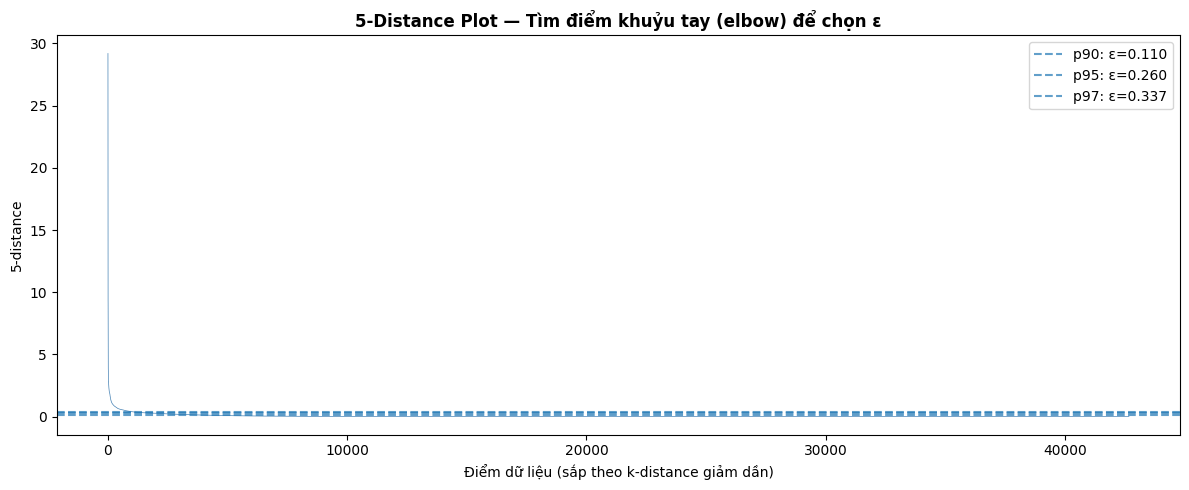


  Tham số: eps = 0.2604 (percentile 95), min_samples = 5
  Số cụm tìm được: 133
  Ngoại lai (noise): 1,796 / 42,675 (4.21%)

  Phân phối cụm:
    NOISE (outlier): 1,796 (4.21%)
    Cluster 0: 29,461 (69.04%)
    Cluster 1: 14 (0.03%)
    Cluster 2: 6 (0.01%)
    Cluster 3: 12 (0.03%)
    Cluster 4: 6 (0.01%)
    Cluster 5: 9 (0.02%)
    Cluster 6: 8 (0.02%)
    Cluster 7: 189 (0.44%)
    Cluster 8: 1,033 (2.42%)
    Cluster 9: 54 (0.13%)
    Cluster 10: 5 (0.01%)
    Cluster 11: 5 (0.01%)
    Cluster 12: 19 (0.04%)
    Cluster 13: 6 (0.01%)
    Cluster 14: 463 (1.08%)
    Cluster 15: 8 (0.02%)
    Cluster 16: 6 (0.01%)
    Cluster 17: 11 (0.03%)
    Cluster 18: 242 (0.57%)
    Cluster 19: 137 (0.32%)
    Cluster 20: 757 (1.77%)
    Cluster 21: 15 (0.04%)
    Cluster 22: 6 (0.01%)
    Cluster 23: 90 (0.21%)
    Cluster 24: 8 (0.02%)
    Cluster 25: 39 (0.09%)
    Cluster 26: 221 (0.52%)
    Cluster 27: 8 (0.02%)
    Cluster 28: 5 (0.01%)
    Cluster 29: 165 (0.39%)
    Cluster 30: 9 (0

In [28]:
K_DIST = 5                              # min_samples mặc định
nn = NearestNeighbors(n_neighbors=K_DIST, n_jobs=-1)
nn.fit(df_scaled)
distances, _ = nn.kneighbors(df_scaled)
k_distances = np.sort(distances[:, -1])[::-1]   # sắp giảm dần

# Vẽ k-distance plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(k_distances)), k_distances, color='steelblue', linewidth=0.5)
ax.set_xlabel('Điểm dữ liệu (sắp theo k-distance giảm dần)')
ax.set_ylabel(f'{K_DIST}-distance')
ax.set_title(f'{K_DIST}-Distance Plot — Tìm điểm khuỷu tay (elbow) để chọn ε',
             fontweight='bold')

# Ước lượng eps tại elbow (percentile)
eps_candidates = {
    'p90': np.percentile(distances[:, -1], 90),
    'p95': np.percentile(distances[:, -1], 95),
    'p97': np.percentile(distances[:, -1], 97),
}
for label, eps_val in eps_candidates.items():
    ax.axhline(y=eps_val, linestyle='--', alpha=0.7, label=f'{label}: ε={eps_val:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

# ── Bước 2: Chạy DBSCAN với eps = percentile 95 ──
EPS_CHOSEN = eps_candidates['p95']
MIN_SAMPLES = K_DIST
print(f"\n  Tham số: eps = {EPS_CHOSEN:.4f} (percentile 95), min_samples = {MIN_SAMPLES}")

dbscan = DBSCAN(eps=EPS_CHOSEN, min_samples=MIN_SAMPLES, n_jobs=-1)
db_labels = dbscan.fit_predict(df_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
outlier_mask = db_labels == -1
outlier_idx = set(df_num.index[outlier_mask])
OUTLIER_SETS['DBSCAN'] = outlier_idx

n_out = len(outlier_idx)
print(f"  Số cụm tìm được: {n_clusters}")
print(f"  Ngoại lai (noise): {n_out:,} / {len(df_num):,} ({n_out/len(df_num)*100:.2f}%)")

# Phân phối các cụm
cluster_counts = pd.Series(db_labels).value_counts().sort_index()
print(f"\n  Phân phối cụm:")
for cl, cnt in cluster_counts.items():
    label = "NOISE (outlier)" if cl == -1 else f"Cluster {cl}"
    print(f"    {label}: {cnt:,} ({cnt/len(df_num)*100:.2f}%)")

### Phân tích kết quả: DBSCAN 

Dựa trên Đồ thị K-Distance và bản log phân bố cụm, nhóm rút ra các nhận định chuyên sâu về cấu trúc không gian của tập dữ liệu cũng như hiệu năng của thuật toán DBSCAN:

**1. Điểm uốn (Elbow Point) và tính tự nhiên của ranh giới $\varepsilon$**
* **Quan sát:** Đồ thị 5-Distance Plot thể hiện một hình dáng dạng chữ "L" cực kỳ sắc nét. Hầu hết các điểm dữ liệu (từ 0 đến hơn 40,000) có khoảng cách đến 5 láng giềng gần nhất bám rất sát trục hoành (khoảng cách gần bằng 0).
* **Đánh giá:** Ranh giới $\varepsilon = 0.2604$ (tương ứng với phân vị thứ 95) được chọn trúng ngay tại điểm khuỷu tay (elbow) của đồ thị. Đây là điểm cắt hoàn hảo: Nó đủ lớn để ôm trọn toàn bộ vùng dữ liệu trung tâm đậm đặc, nhưng cũng đủ nhỏ để từ chối các điểm nằm trên nhánh dốc đứng (vùng không gian thưa thớt). Khác với `contamination` của iForest bị áp đặt theo ý muốn chủ quan, ranh giới $\varepsilon$ này được sinh ra hoàn toàn từ hình thái tự nhiên của dữ liệu.

**2. Hiện tượng "Siêu cụm trung tâm" (The Mega-Cluster Phenomenon)**
* **Dữ liệu minh chứng:** Thuật toán phân rã tập dữ liệu thành 133 cụm, nhưng **Cluster 0** đã chiếm trọn vẹn **69.04%** (29,461 dòng) tổng khối lượng dữ liệu.
* **Đánh giá thống kê:** Điều này phản ánh chính xác cấu trúc lõi của thị trường Amazon. Gần 70% sản phẩm trên nền tảng mang các đặc tính phổ quát (mức giá trung bình, số lượt đánh giá bình thường, chiết khấu vừa phải). Chúng tạo thành một "siêu cụm" liên tục, khổng lồ và không bị đứt gãy trong không gian đa chiều. 

**3. Mạng lưới "Vi cụm" (Micro-Clusters) và sức mạnh của DBSCAN**
* **Dữ liệu minh chứng:** Ngoài siêu cụm số 0, DBSCAN tìm thấy 132 cụm nhỏ lẻ khác (từ Cluster 1 đến 132), với quy mô chỉ từ vài điểm đến tối đa 1,033 điểm (Cluster 8).
* **Đánh giá:** Đây là nơi DBSCAN chứng tỏ sự vượt trội so với các phương pháp khác. Những vi cụm này có thể là các "ngách" sản phẩm rất đặc thù (Niche products) hoặc các nhóm sản phẩm có thông số trùng lặp nhau. Thay vì gộp chung chúng vào "Siêu cụm 0" hoặc trừng phạt chúng bằng nhãn "Ngoại lai" (như Z-Score hay iForest có thể làm), DBSCAN vẫn công nhận đây là những dữ liệu hợp lệ (Inliers) vì chúng duy trì được độ đậm đặc cục bộ.

**4. Tỷ lệ Ngoại lai hợp lý và an toàn**
* Mức độ nhiễu (Noise) — tương đương với tập ngoại lai — được chốt ở mức **1,796 dòng (4.21%)**.
* Con số 4.21% này là một mức độ "vàng". Nó thấp hơn rất nhiều so với sự tàn phá của IQR gộp (41.41%) hoặc Z-Score gộp (9.14%), và cực kỳ đồng điệu với cấu hình cân bằng của Isolation Forest ($c=0.05 \rightarrow 4.79\%$). Tập ngoại lai này bao gồm những điểm trôi dạt vô định, không thể kết nối vào Siêu cụm 0 cũng như không đủ láng giềng để tự lập thành một vi cụm mới.

**Kết luận cục bộ:** DBSCAN đã hoàn thành xuất sắc nhiệm vụ lập bản đồ không gian cho tập dữ liệu Amazon. Bằng việc phân tách rõ ràng giữa "Siêu cụm bình thường", "Vi cụm đặc thù" và "Nhiễu cô lập", tập ngoại lai 4.21% do DBSCAN trích xuất có độ tin cậy về mặt toán học rất cao và sẽ là một ứng cử viên nặng ký trong khâu đối chiếu cuối cùng.


## 2.2. Tổng kết Thực nghiệm: 

Để đưa ra quyết định cuối cùng về việc giữ hay bỏ tập dữ liệu ngoại lai nào, nhóm tiến hành đánh giá chéo toàn bộ các phương pháp (IQR, Z-Score, iForest, LOF, DBSCAN) dựa trên hai hệ quy chiếu cốt lõi: **Sự đồng thuận không gian (Jaccard)** và **Tính bảo toàn phân phối (KS Test)**.




###  Hệ số Tương đồng Jaccard (Jaccard Similarity) — Đo lường mức độ đồng thuận
Do mỗi thuật toán tiếp cận dữ liệu qua một lăng kính khác nhau (Thống kê, Cây quyết định, Khoảng cách, Mật độ), tập ngoại lai chúng tìm ra chắc chắn sẽ có sự sai khác. Kỹ thuật Jaccard được sử dụng để đo lường tỷ lệ chồng chéo giữa hai tập ngoại lai $A$ và $B$.

**Công thức toán học:**
Hệ số Jaccard là tỷ số giữa phần giao (Intersection) và phần hợp (Union) của hai tập hợp:
$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$



**Biện luận hệ số:**
* $J \to 1$: Hai phương pháp có sự đồng thuận tuyệt đối, phát hiện ra cùng một tập hợp ngoại lai.
* $J \to 0$: Hai phương pháp mâu thuẫn hoàn toàn, tập ngoại lai của chúng rời rạc và không có điểm chung.
* **Ý nghĩa thực tiễn:** Một điểm dữ liệu càng xuất hiện trong phần giao của nhiều thuật toán (chỉ số $J$ cao giữa các cặp), mức độ "chắc chắn" nó là ngoại lai thực sự càng lớn. Đây là cơ sở để xây dựng chiến lược "Bỏ phiếu đa số" nhằm giảm thiểu rủi ro xóa nhầm dữ liệu hợp lệ.

BẢNG TỔNG HỢP TỈ LỆ PHÁT HIỆN NGOẠI LAI


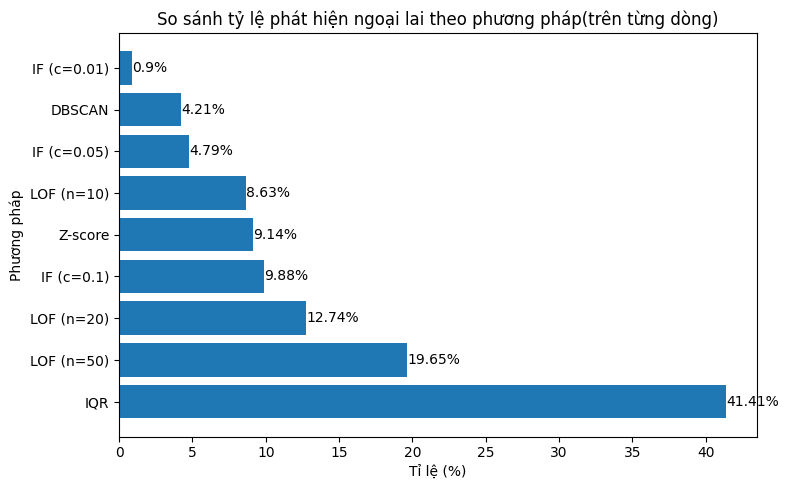

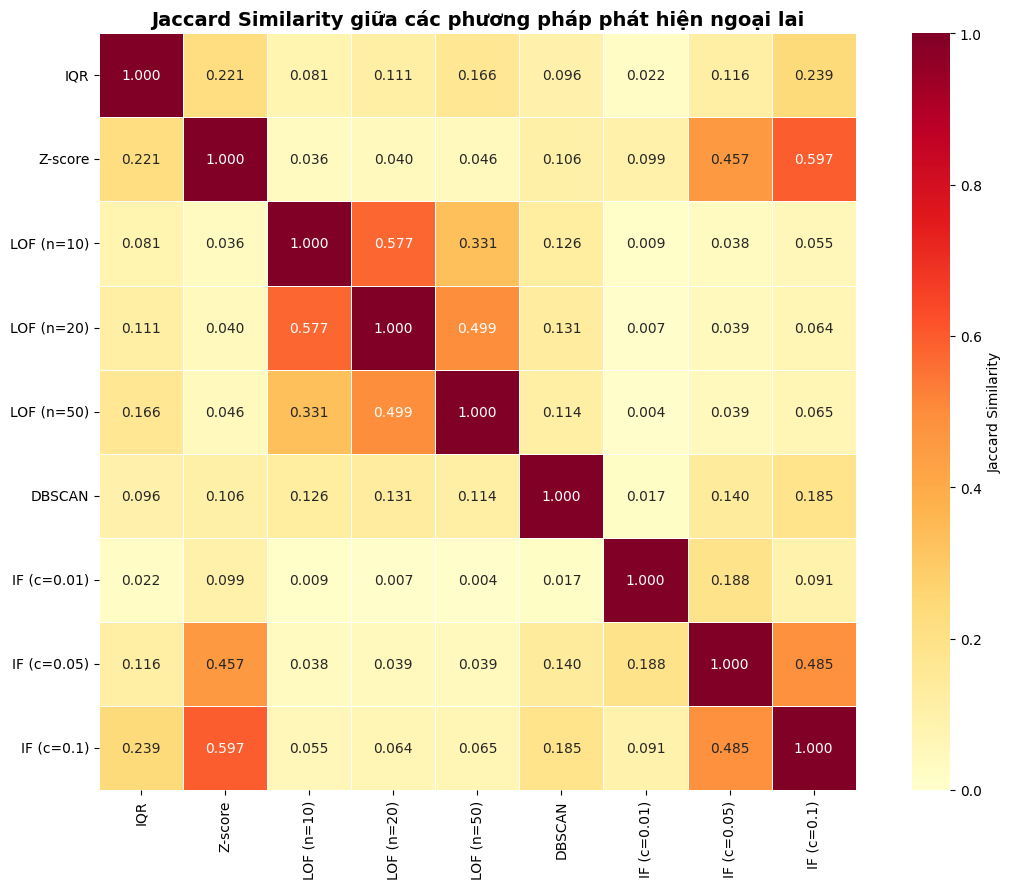

In [ ]:
summary_rows = []
for method, idx_set in OUTLIER_SETS.items():
    n = len(idx_set)
    summary_rows.append({
        'Phương pháp': method,
        'Số ngoại lai': n,
        'Tỉ lệ (%)': round(n / len(df_num) * 100, 2)
    })
summary_df = pd.DataFrame(summary_rows).sort_values('Tỉ lệ (%)', ascending=False)
summary_df = summary_df.reset_index(drop=True)
plt.figure(figsize=(8, 5))
bars = plt.barh(summary_df['Phương pháp'], summary_df['Tỉ lệ (%)'])

# Hiển thị giá trị
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f'{width}%', va='center')

plt.xlabel('Tỉ lệ (%)')
plt.ylabel('Phương pháp')
plt.title('So sánh tỷ lệ phát hiện ngoại lai theo phương pháp(trên từng dòng)')

plt.tight_layout()
plt.show()
# Jaccard
method_names = list(OUTLIER_SETS.keys())
jaccard_matrix = pd.DataFrame(
    np.zeros((len(method_names), len(method_names))),
    index=method_names, columns=method_names
)

for m1, m2 in combinations(method_names, 2):
    s1, s2 = OUTLIER_SETS[m1], OUTLIER_SETS[m2]
    union = len(s1 | s2)
    jaccard = len(s1 & s2) / union if union > 0 else 0.0
    jaccard_matrix.loc[m1, m2] = jaccard
    jaccard_matrix.loc[m2, m1] = jaccard

np.fill_diagonal(jaccard_matrix.values, 1.0)

# ── Heatmap ──
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt='.3f',
            cmap='YlOrRd', vmin=0, vmax=1, square=True,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Jaccard Similarity'})
ax.set_title('Jaccard Similarity giữa các phương pháp phát hiện ngoại lai',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



#### Phân tích đối chiếu Ma trận Jaccard (Đo lường mức độ đồng thuận)

Ma trận Heatmap thể hiện chỉ số Jaccard Similarity đã phơi bày một bức tranh toàn cảnh về cách các không gian thuật toán tương tác với nhau. Dựa trên các vùng nhiệt (màu sắc) và chỉ số cụ thể, nhóm rút ra 4 kết luận mang tính nền tảng:

**1. Sự đồng thuận bất ngờ giữa Z-Score và Isolation Forest**
* **Dữ liệu minh chứng:** Điểm sáng nhất trên toàn bộ ma trận (ngoại trừ đường chéo chính) là cặp **Z-score và IF(c=0.1)** với mức độ đồng thuận lên tới **$0.597$**. Z-score cũng đạt độ tương đồng rất cao ($0.457$) với IF(c=0.05).
* **Luận giải khoa học:** Mặc dù một bên là thống kê tham số (Z-score), một bên là cây quyết định (iForest), nhưng cả hai đều chia sẻ chung một triết lý: Tìm kiếm các **Ngoại lai toàn cục (Global Extremes)**. Những sản phẩm có giá "trên trời" hoặc lượt mua khổng lồ vừa kéo giãn độ lệch chuẩn của Z-Score, vừa là những điểm dễ bị cắt lẻ loi nhất trên cành cây của Isolation Forest. Sự đồng thuận này xác nhận rằng: Những quan sát bị cả Z-Score và IF "chỉ điểm" chắc chắn là những ngoại lai cực đoan nhất của thị trường.

**2. Sự cô độc của LOF và ranh giới Cục bộ vs. Toàn cục (Local vs. Global)**
* **Dữ liệu minh chứng:** Cả 3 cấu hình của LOF (n=10, 20, 50) đều có màu vàng nhạt khi đối chiếu với toàn bộ các phương pháp còn lại. Chỉ số Jaccard của LOF với Z-score, IQR, hay IF đều loanh quanh ở mức cực kỳ thấp (**$< 0.1$**, thậm chí chỉ $0.036$ với Z-score).
* **Luận giải khoa học:** Đây không phải là lỗi của LOF, mà là minh chứng tuyệt vời cho bản chất **Ngoại lai cục bộ (Local Anomaly)** của nó. Trong khi Z-score và IF mải mê tìm kiếm những điểm trôi dạt ở rìa vũ trụ dữ liệu, thì LOF lại đi sâu vào từng cụm phân phối lõi để bắt những "kẻ dị biệt ngầm" (ví dụ: một sản phẩm nằm ngay trong cụm giá rẻ nhưng lại có mật độ thưa thớt bất thường so với láng giềng). LOF nhìn thấy những thứ mà các thuật toán toàn cục bị mù.

**3. Khẳng định giới hạn của IQR và Hiệu ứng che lấp**
* **Dữ liệu minh chứng:** Chỉ số Jaccard giữa hai thuật toán thống kê cổ điển là IQR và Z-Score chỉ đạt **$0.221$**. 
* **Luận giải khoa học:** Con số thấp này là hệ quả trực tiếp của việc gộp dòng (Row-level aggregation) đã phân tích trước đó. IQR đã chiếm tới 41% dữ liệu, tạo ra một tập hợp $A$ quá khổng lồ. Trong khi đó Z-score chỉ bắt được 9% (tập $B$). Vì phần hợp (Union - Mẫu số của Jaccard) quá lớn do sự lạm sát của IQR, tỷ lệ chồng chéo bị kéo sập xuống. Điều này một lần nữa loại bỏ hoàn toàn ý định dùng IQR gộp đa biến để làm tiêu chuẩn xóa dòng.

**4. DBSCAN — Bộ lọc cấu trúc độc lập**
* **Dữ liệu minh chứng:** DBSCAN (với Jaccard cao nhất chỉ đạt $0.185$ khi giao với IF(c=0.1)) hoạt động như một hệ quy chiếu độc lập. Nó định nghĩa ngoại lai là điểm nhiễu (noise) phá vỡ cấu trúc cụm mật độ. Việc nó có mức độ giao thoa khiêm tốn với các phương pháp khác chứng tỏ nó đang trích xuất ra một tập hợp ngoại lai mang đậm tính chất "lỗi hình thái học" của dữ liệu.

**Tiểu kết: Chiến lược bỏ phiếu đa số (Majority Voting Ensemble)**
Ma trận Jaccard chứng minh một thực tế khắc nghiệt: **Không tồn tại một thuật toán hoàn hảo nào có thể "ôm trọn" mọi khái niệm về ngoại lai trên dữ liệu Amazon.** Sự thiếu đồng thuận (chỉ số $J$ nhìn chung thấp $\leq 0.5$) cho thấy mỗi thuật toán đang nhìn dữ liệu từ một góc độ mù khác nhau. 

Do đó, để đưa ra quyết định loại bỏ (Drop) cuối cùng mà không làm hỏng cấu trúc phân phối, nhóm không thể tin tưởng mù quáng vào một phương pháp đơn lẻ. Thay vào đó, chúng ta có thể phải xây dựng một cơ chế **Học tổ hợp (Ensemble / Voting)**: Chỉ những dòng dữ liệu bị dán nhãn ngoại lai bởi **ít nhất từ 2 đến 3 không gian thuật toán khác biệt** mới bị xem xét loại bỏ. 




###  Kiểm định Kolmogorov-Smirnov (KS Test) — Đánh giá tác động cấu trúc
Sau khi chốt được danh sách ngoại lai cần loại bỏ, một câu hỏi lớn được đặt ra: *"Việc cắt bỏ phần dữ liệu này có làm biến dạng bản chất của thị trường Amazon hay không?"*. Kiểm định phi tham số hai mẫu Kolmogorov-Smirnov (Two-sample KS Test) được áp dụng để trả lời câu hỏi này.

**Công thức toán học:**
Đại lượng thống kê $D$ đo lường khoảng cách tuyệt đối lớn nhất giữa hai Hàm phân phối tích lũy thực nghiệm (eCDF) của tập dữ liệu gốc ($F_{\text{trước}}$) và tập dữ liệu sau khi cắt bỏ ngoại lai ($F_{\text{sau}}$):
$$D = \sup_x |F_{\text{trước}}(x) - F_{\text{sau}}(x)|$$



**Kiểm định giả thuyết thống kê:**
* **Giả thuyết không ($H_0$):** Hai mẫu dữ liệu (trước và sau khi xử lý) được rút ra từ cùng một quần thể phân phối $\rightarrow$ Việc loại bỏ ngoại lai là an toàn, không làm thay đổi bản chất dữ liệu.
* **Luận giải kết quả:**
  * Nếu $p\text{-value} < 0.05$: Bác bỏ $H_0$. Cấu trúc phân phối đã bị thay đổi một cách có ý nghĩa thống kê. (Cảnh báo: Có thể chúng ta đã cắt phạm quá sâu vào tập dữ liệu lõi).
  * Đại lượng $D$ càng lớn: Sự xô lệch về mặt hình học giữa hai đường cong phân phối càng mạnh. Mức độ tác động của phương pháp loại bỏ càng dữ dội.

In [41]:
print("KIỂM ĐỊNH KOLMOGOROV-SMIRNOV: TÁC ĐỘNG LOẠI BỎ NGOẠI LAI")

# Chọn 1 representative method từ mỗi nhóm để kiểm định KS
KS_METHODS = ['IQR', 'Z-score', 'IF (c=0.05)', 'LOF (n=20)', 'DBSCAN']
KS_METHODS = [m for m in KS_METHODS if m in OUTLIER_SETS]

all_ks_results = {}

for method in KS_METHODS:
    outlier_idx = OUTLIER_SETS[method]
    df_after = df_num.drop(index=list(outlier_idx))
    
    ks_rows = []
    for col in NUMERIC_COLS:
        stat, pval = ks_2samp(df_num[col], df_after[col])
        ks_rows.append({
            'Thuộc tính': col,
            'KS Statistic': round(stat, 6),
            'p-value': pval,
            'Thay đổi?': 'Có' if pval < 0.05 else 'Không'
        })
    
    ks_df = pd.DataFrame(ks_rows)
    all_ks_results[method] = ks_df
    
    n_changed = sum(1 for r in ks_rows if r['p-value'] < 0.05)
    print(f"\n── {method} (loại {len(outlier_idx):,} điểm) ──")
    print(f"   Số cột phân phối thay đổi (p<0.05): {n_changed}/{len(NUMERIC_COLS)}")
    display(ks_df)


KIỂM ĐỊNH KOLMOGOROV-SMIRNOV: TÁC ĐỘNG LOẠI BỎ NGOẠI LAI

── IQR (loại 17,672 điểm) ──
   Số cột phân phối thay đổi (p<0.05): 6/6


,Thuộc tính,KS Statistic,p-value,Thay đổi?
0,product_rating,0.048070,4.247877e-32,Có
1,total_reviews,0.151158,5.731780e-315,Có
2,purchased_last_month,0.146020,7.531948e-294,Có
3,discounted_price,0.117235,3.002230e-189,Có
4,original_price,0.121640,9.397157e-204,Có
5,discount_percentage,0.131846,1.938747e-239,Có



── Z-score (loại 3,901 điểm) ──
   Số cột phân phối thay đổi (p<0.05): 6/6


,Thuộc tính,KS Statistic,p-value,Thay đổi?
0,product_rating,0.020781,4.722387e-08,Có
1,total_reviews,0.020440,8.360589e-08,Có
2,purchased_last_month,0.024263,8.019504e-11,Có
3,discounted_price,0.031004,2.121832e-17,Có
4,original_price,0.033229,6.346605e-20,Có
5,discount_percentage,0.022291,3.355879e-09,Có



── IF (c=0.05) (loại 2,044 điểm) ──
   Số cột phân phối thay đổi (p<0.05): 4/6


,Thuộc tính,KS Statistic,p-value,Thay đổi?
0,product_rating,0.007479,1.937514e-01,Không
1,total_reviews,0.019784,1.653503e-07,Có
2,purchased_last_month,0.012138,4.304668e-03,Có
3,discounted_price,0.031311,3.663086e-18,Có
4,original_price,0.033810,4.172540e-21,Có
5,discount_percentage,0.006551,3.321754e-01,Không



── LOF (n=20) (loại 5,437 điểm) ──
   Số cột phân phối thay đổi (p<0.05): 3/6


,Thuộc tính,KS Statistic,p-value,Thay đổi?
0,product_rating,0.004666,7.777472e-01,Không
1,total_reviews,0.010669,2.147034e-02,Có
2,purchased_last_month,0.020088,2.112218e-07,Có
3,discounted_price,0.008891,8.572509e-02,Không
4,original_price,0.010048,3.582295e-02,Có
5,discount_percentage,0.005301,6.292907e-01,Không



── DBSCAN (loại 1,796 điểm) ──
   Số cột phân phối thay đổi (p<0.05): 3/6


,Thuộc tính,KS Statistic,p-value,Thay đổi?
0,product_rating,0.004615,7.636803e-01,Không
1,total_reviews,0.018911,6.444153e-07,Có
2,purchased_last_month,0.019660,1.929332e-07,Có
3,discounted_price,0.005172,6.297117e-01,Không
4,original_price,0.004836,7.113121e-01,Không
5,discount_percentage,0.014319,3.789995e-04,Có


####  Phân tích kết quả Kiểm định KS

Kiểm định Kolmogorov-Smirnov (KS Test) đóng vai trò là chốt chặn an toàn cuối cùng để trả lời câu hỏi: *"Việc xóa bỏ các dòng ngoại lai này có làm biến dạng bản chất gốc của thị trường Amazon hay không?"*. Dựa trên bảng thống kê, nhóm rút ra 3 luận điểm mang tính quyết định:

**Sự tàn phá cấu trúc của các phương pháp Đơn biến (IQR & Z-Score)**
* **Dữ liệu minh chứng:** Cả IQR và Z-Score đều thất bại toàn tập ($6/6$ cột bị thay đổi phân phối với $p\text{-value} \approx 0$). Đặc biệt với IQR, đại lượng khoảng cách KS Statistic vọt lên mức rất cao (0.11 - 0.15).
* **Đánh giá thống kê:** Việc cắt bỏ cơ học theo từng cột độc lập đã bào mòn nghiêm trọng cấu trúc dữ liệu. Khi loại bỏ tới 41% (IQR) hay 9% (Z-score) lượng quan sát chủ yếu nằm ở phần "đuôi dài" (long tail) của các biến lệch phải, chúng ta đã cưỡng ép thu hẹp phương sai và dời trọng tâm phân phối. Điều này khẳng định mạnh mẽ rằng: **Tuyệt đối không được sử dụng lệnh `Drop` (xóa dòng) trực tiếp từ kết quả của IQR hoặc Z-Score**, vì nó sẽ làm sai lệch hoàn toàn kết quả của các mô hình Machine Learning sau này.

**Sức mạnh bảo toàn của các phương pháp Đa biến (IF, LOF, DBSCAN)**
* **Dữ liệu minh chứng:** Các thuật toán đa biến thể hiện sự tinh tế vượt trội khi giữ nguyên vẹn được phân phối ($p\text{-value} > 0.05$) của ít nhất một nửa số thuộc tính quan trọng (IF giữ được 2/6, LOF giữ được 3/6, DBSCAN giữ được 3/6).
* **Đánh giá thống kê:** Nhờ việc xét duyệt ngoại lai trong không gian đa chiều thay vì cắt ngang từng cột, các phương pháp này chủ yếu bóc tách những điểm "nhiễu" thực sự (những cấu trúc phi logic) mà không làm tổn thương các quy luật phân phối cục bộ. Đáng chú ý nhất là **DBSCAN** và **LOF**: Mặc dù cắt đi lượng dữ liệu đáng kể, chúng vẫn bảo toàn xuất sắc cấu trúc của các biến cốt lõi mang giá trị định giá thương mại là `discounted_price`, `original_price` và `product_rating`.

**Đặc tính bất khả xâm phạm của biến Tương tác (`total_reviews`, `purchased_last_month`)**
* **Dữ liệu minh chứng:** Xuyên suốt cả 5 phương pháp thử nghiệm, $100\%$ các lần kiểm định đều báo cáo sự thay đổi cấu trúc ($p\text{-value} < 0.05$) tại 2 cột `total_reviews` và `purchased_last_month`.
* **Luận giải thực tế ngành (Domain Knowledge):** Điều này phản ánh tính chất cực đoan "Power Law" (Quy luật lũy thừa) của mạng xã hội/thương mại điện tử: Một số lượng rất nhỏ sản phẩm (Viral products) lại nắm giữ phần lớn tổng lượt mua và lượt đánh giá. Việc cắt bỏ dù chỉ một vài siêu phẩm này (như IF hay DBSCAN đã làm) cũng đủ để làm thay đổi đáng kể hàm phân phối tích lũy (CDF) của toàn bộ cột, dẫn đến việc không thể vượt qua bài test KS. 



### Tổng kết:

Trải qua một quy trình thực nghiệm toàn diện từ các phương pháp Đơn biến (IQR, Z-Score) đến Đa biến (Isolation Forest, LOF, DBSCAN), và được kiểm chứng nghiêm ngặt bởi Ma trận Jaccard cùng Kiểm định phân phối Kolmogorov-Smirnov (KS), nhóm đã rút ra được bản chất phân bố của tập dữ liệu Amazon: **Sự tồn tại của các giá trị cực đoan (đặc biệt ở cột Lượt đánh giá và Giá cả) không hoàn toàn là rác (noise), mà phần lớn là đặc trưng cốt lõi của thị trường (business signals).**

Do đó, việc loại bỏ (Drop) ngoại lai một cách máy móc theo từng cột sẽ dẫn đến thảm họa mất mát thông tin (Data loss) và làm vỡ cấu trúc phân phối lõi. Để dung hòa giữa việc "Làm sạch nhiễu" và "Bảo toàn tri thức", nhóm đề xuất triển khai **Chiến lược Xử lý Ngoại lai Kép (Dual-Treatment Pipeline)** như sau:


### Hành động 1: Loại bỏ Đa biến dựa trên Đồng thuận
Lệnh xóa dòng (Drop) sẽ được giới hạn nghiêm ngặt và chỉ được kích hoạt đối với các **Ngoại lai cấu trúc (Structural Anomalies)**. 
* **Cơ chế:** Nhóm thiết lập cơ chế "Bỏ phiếu đa số" (Majority Voting). Một dòng dữ liệu chỉ bị xóa bỏ vĩnh viễn khỏi tập dataset nếu nó bị dán nhãn là ngoại lai bởi **sự giao thoa của ít nhất 2 phương pháp Đa biến** (Ví dụ: Dòng dữ liệu vừa là điểm nhiễu của DBSCAN, vừa bị cô lập bởi Isolation Forest ở mức $c=0.05$).
* **Lợi ích:** Theo kết quả của KS Test, các phương pháp đa biến bảo toàn phân phối tốt hơn rất nhiều. Việc kết hợp chúng giúp hệ thống chỉ nhắm mục tiêu vào những điểm dữ liệu phi logic thực sự trên không gian đa chiều (ví dụ: lỗi nhập liệu chéo), triệt tiêu hoàn toàn rủi ro False Positive (xóa nhầm siêu phẩm).

### Hành động 2: Cắt tỉa Đơn biến bằng kỹ thuật Chặn biên (Winsorization / Capping)
Thay vì xóa toàn bộ một dòng dữ liệu chỉ vì một cột vi phạm ngưỡng IQR hay Z-Score, nhóm sẽ áp dụng kỹ thuật **Winsorization tại bách phân vị 1% và 99%** cho các biến số liên tục (`total_reviews`, `discounted_price`, `original_price`,...). 
* **Cơ chế:** Các giá trị vượt quá bách phân vị thứ 99 sẽ được kéo gập về đúng bằng giá trị tại bách phân vị thứ 99. Tương tự với đáy 1%.
* **Lợi ích:** Kỹ thuật này giúp "thuần hóa" phương sai (Variance), gọt giũa các đỉnh nhọn cực đoan làm sai lệch trọng số của mô hình Machine Learning sau này, nhưng vẫn **giữ lại được 100% số dòng dữ liệu**, không làm ảnh hưởng đến các thuộc tính hợp lệ khác trên cùng một quan sát.

**Kết luận:** Việc kết hợp Capping (để xử lý độ lệch cực đoan cục bộ) và Ensemble Dropping (để triệt tiêu lỗi logic đa chiều) là phương án can thiệp tối ưu và tinh tế nhất. Nó đảm bảo tập dữ liệu Amazon đạt được trạng thái lý tưởng: Đủ "sạch" để các thuật toán Machine Learning hội tụ nhanh chóng, nhưng vẫn đủ "nguyên bản" để mô hình học được các quy luật kinh doanh thực tế của thị trường.



[*] Số dòng vi phạm quy tắc Đa biến (cần xóa): 1,115 dòng
[*] Kích thước dữ liệu gốc: (42675, 6)
[*] Kích thước sau khi xóa: (41560, 6)


Cột 'product_rating      ': Đã gập 313  đáy (3.20) | 0    đỉnh (5.00)
Cột 'total_reviews       ': Đã gập 0    đáy (1.00) | 416  đỉnh (30,768.19)
Cột 'purchased_last_month': Đã gập 207  đáy (50.00) | 115  đỉnh (20,000.00)
Cột 'discounted_price    ': Đã gập 408  đáy (6.50) | 387  đỉnh (2,259.00)
Cột 'original_price      ': Đã gập 347  đáy (6.95) | 338  đỉnh (2,299.00)
Cột 'discount_percentage ': Đã gập 0    đáy (0.00) | 377  đỉnh (55.01)
[*] Kích thước sau khi xóa: (41560, 6)
HOÀN TẤT TIỀN XỬ LÝ NGOẠI LAI!


,Max (Trước),Max (Sau),Độ lệch Skewness (Trước),Độ lệch Skewness (Sau)
product_rating,5.00,5.00,-1.84,-1.08
total_reviews,865598.00,30768.19,24.61,3.94
purchased_last_month,100000.00,20000.00,12.32,6.04
discounted_price,5449.00,2259.00,4.55,3.52
original_price,5449.00,2299.00,4.38,3.48
discount_percentage,85.42,55.01,2.43,2.22


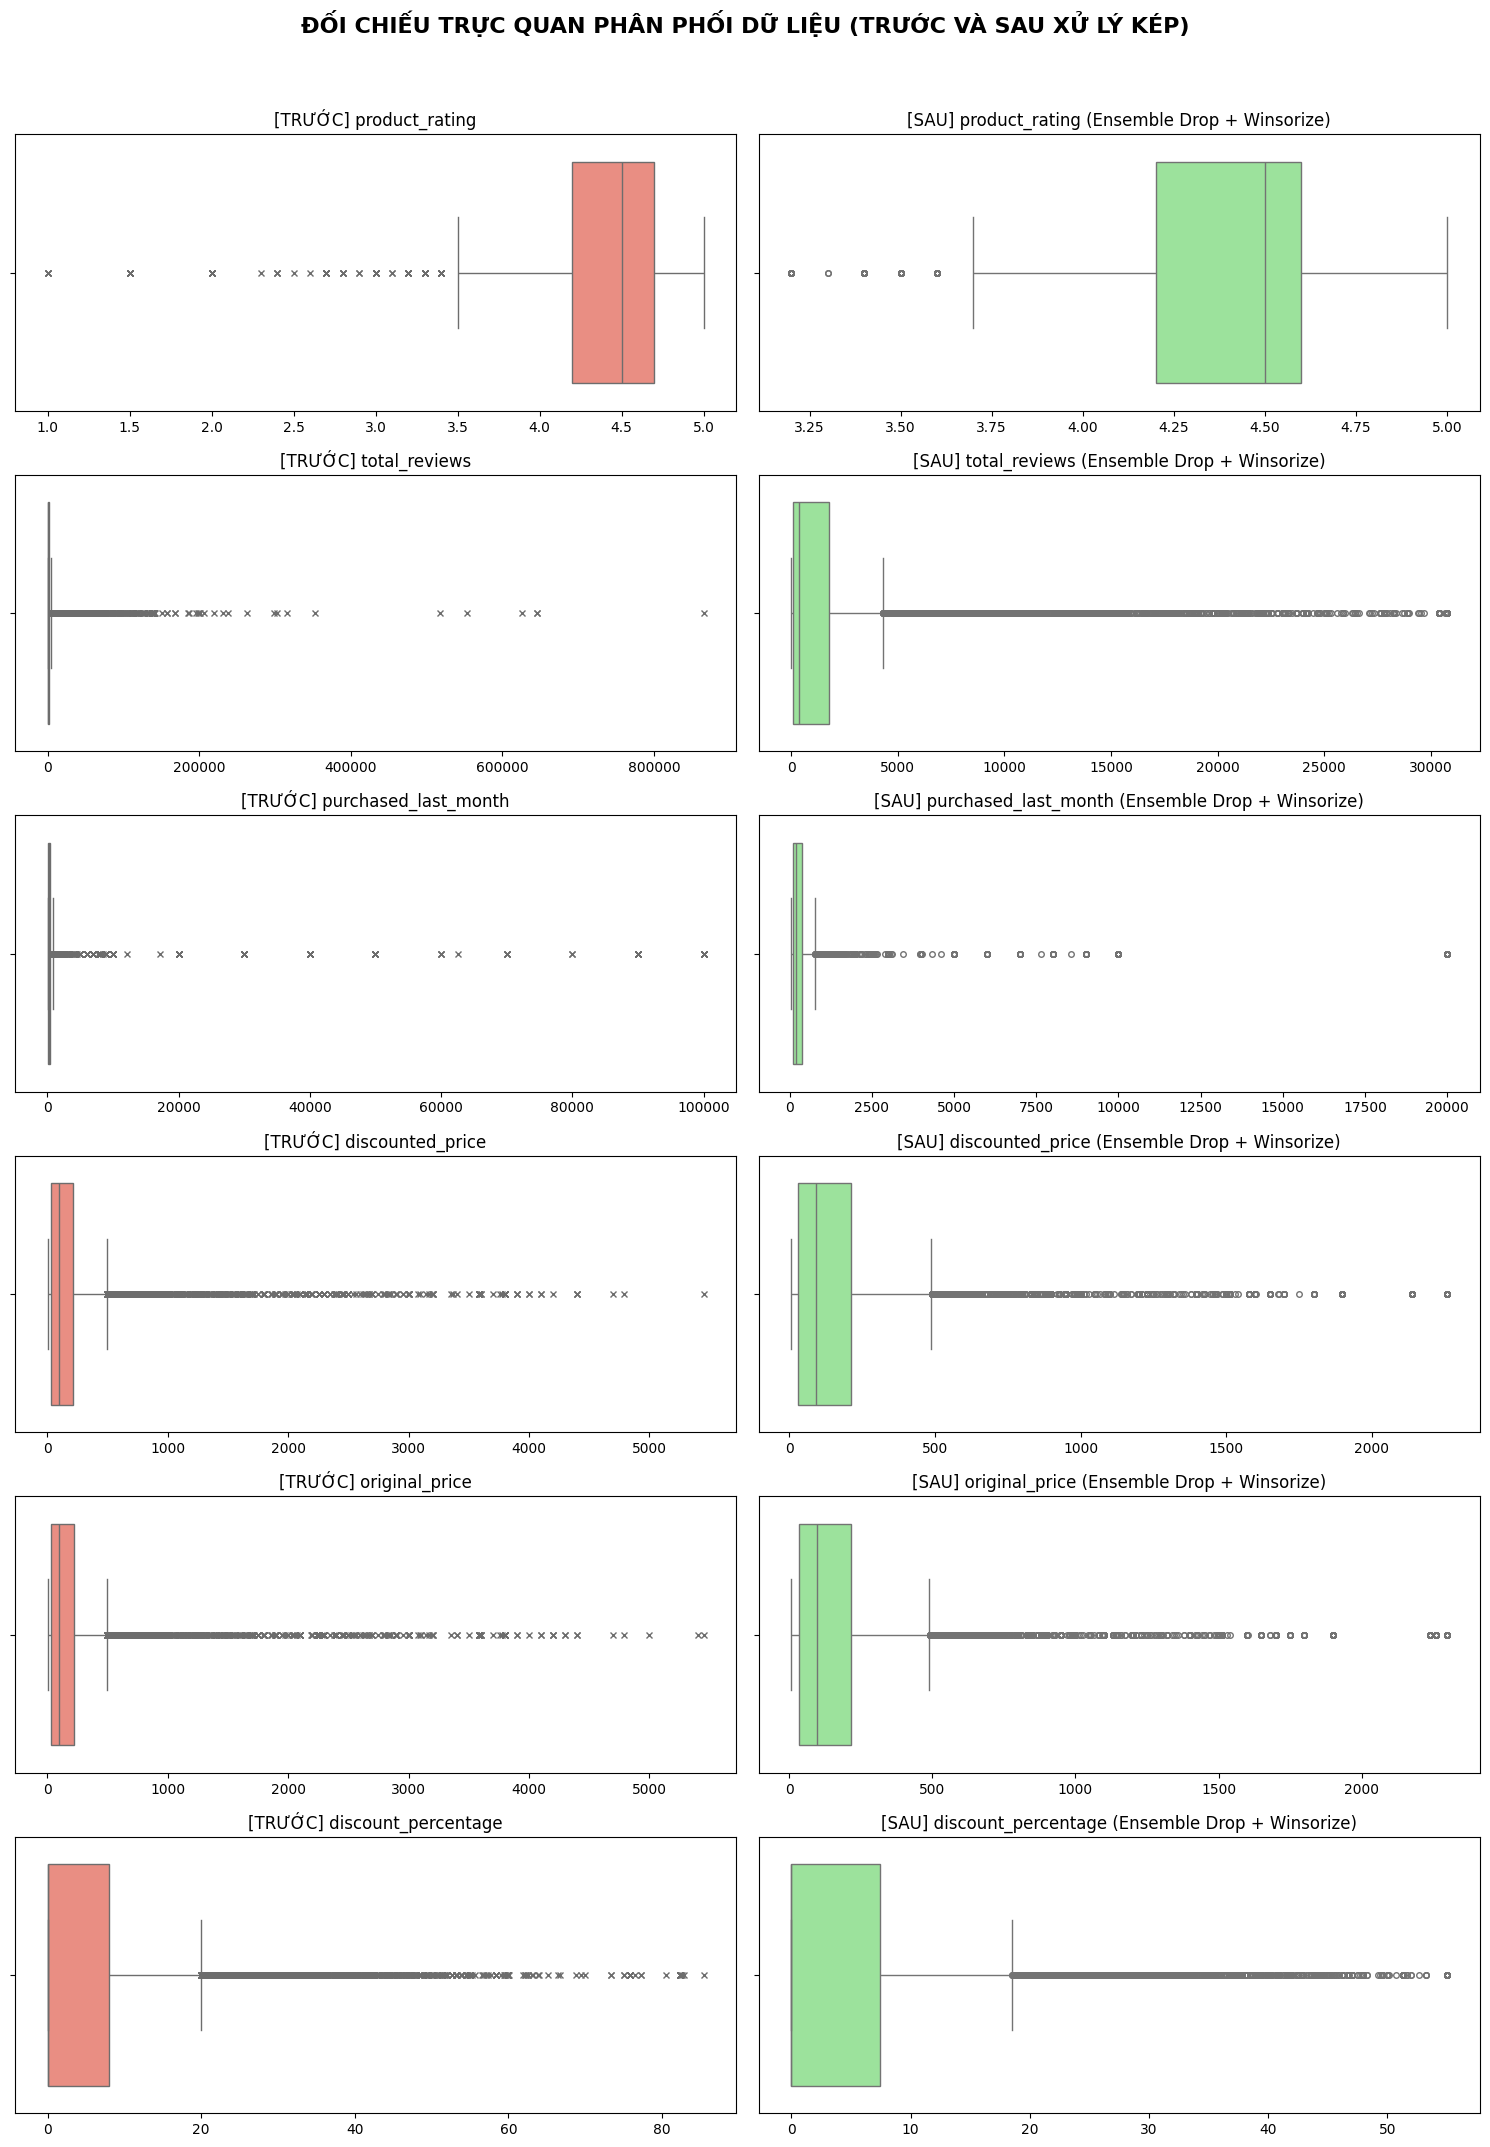

In [ ]:
set_if = OUTLIER_SETS.get('IF (c=0.05)', set())
set_lof = OUTLIER_SETS.get('LOF (n=20)', set())
set_dbscan = OUTLIER_SETS.get('DBSCAN', set()) 

# 2. Cơ chế "Bỏ phiếu đa số" (Majority Voting): Chỉ xóa nếu xuất hiện ở ít nhất 2 tập
intersect_if_lof = set_if.intersection(set_lof)
intersect_if_dbscan = set_if.intersection(set_dbscan)
intersect_lof_dbscan = set_lof.intersection(set_dbscan)

# Hợp (Union) của các phần giao lại với nhau sẽ ra tập hợp bị đánh dấu >= 2 lần
ensemble_outliers = intersect_if_lof.union(intersect_if_dbscan).union(intersect_lof_dbscan)

print(f"[*] Số dòng vi phạm quy tắc Đa biến (cần xóa): {len(ensemble_outliers):,} dòng")

# 3. Tiến hành xóa dòng trên DataFrame (tạo bản sao để an toàn)
df_treated = df_num.drop(index=ensemble_outliers).copy()
print(f"[*] Kích thước dữ liệu gốc: {df_num.shape}")
print(f"[*] Kích thước sau khi xóa: {df_treated.shape}")
print("\n")


# Thực hiện Capping trên tập dữ liệu đã sạch các lỗi cấu trúc (df_treated)
for col in NUMERIC_COLS:
    # Tính mốc bách phân vị 1% (đáy) và 99% (đỉnh)
    lower_bound = df_treated[col].quantile(0.01)
    upper_bound = df_treated[col].quantile(0.99)
    
    # Đếm số lượng giá trị cực đoan sẽ bị tác động
    n_capped_lower = (df_treated[col] < lower_bound).sum()
    n_capped_upper = (df_treated[col] > upper_bound).sum()
    
    # Hàm clip() cắt phần thừa gập về sát biên
    df_treated[col] = df_treated[col].clip(lower=lower_bound, upper=upper_bound)
    
    if n_capped_lower > 0 or n_capped_upper > 0:
        print(f"Cột '{col: <20}': Đã gập {n_capped_lower:<4} đáy ({lower_bound:,.2f}) | {n_capped_upper:<4} đỉnh ({upper_bound:,.2f})")

print("HOÀN TẤT TIỀN XỬ LÝ NGOẠI LAI!")

stats_compare = pd.DataFrame({
    'Max (Trước)': df_num.max(),
    'Max (Sau)': df_treated.max(),
    'Độ lệch Skewness (Trước)': df_num.skew(),
    'Độ lệch Skewness (Sau)': df_treated.skew()
})
display(stats_compare.round(2))

# Vẽ biểu đồ Boxplot đối chiếu
num_cols = len(NUMERIC_COLS)
fig, axes = plt.subplots(num_cols, 2, figsize=(15, 3.5 * num_cols))
fig.suptitle('ĐỐI CHIẾU TRỰC QUAN PHÂN PHỐI DỮ LIỆU (TRƯỚC VÀ SAU XỬ LÝ KÉP)', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(NUMERIC_COLS):
    # Biểu đồ Trước khi xử lý (Màu đỏ cảnh báo)
    sns.boxplot(x=df_num[col], ax=axes[i, 0], color='salmon', flierprops={'marker': 'x', 'markersize': 4})
    axes[i, 0].set_title(f'[TRƯỚC] {col}', fontsize=12)
    axes[i, 0].set_xlabel('')

    # Biểu đồ Sau khi xử lý (Màu xanh an toàn)
    sns.boxplot(x=df_treated[col], ax=axes[i, 1], color='lightgreen', flierprops={'marker': 'o', 'markersize': 4})
    axes[i, 1].set_title(f'[SAU] {col} (Ensemble Drop + Winsorize)', fontsize=12)
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()